# NexaSat Digital Wallet: AI-Driven Customer Lifetime Value Prediction for Customer Analytics and Personalised Marketing

# Machine Learning Modelling

Machine learning models were developed using **Scikit-learn** and advanced gradient boosting frameworks to predict **Customer Lifetime Value (CLV)**.

The modelling approach incorporated a diverse range of regression techniques, including linear regression, decision trees, ensemble learning, kernel-based learning, neural networks, and gradient boosting. This enabled the analysis to capture both linear and complex non-linear relationships between customer demographics, behavioural patterns, transaction characteristics, engagement, and future customer value.

## Regression Models

The following regression models were evaluated:

### 1. Linear Regression

**Linear Regression** was used as the baseline statistical learning model. It establishes a benchmark relationship between customer characteristics and Customer Lifetime Value. Its simplicity and interpretability provide a reference point against which the performance of more complex machine learning models can be assessed.

### 2. Decision Tree Regressor

The **Decision Tree Regressor** is a non-linear tree-based algorithm that recursively partitions the dataset based on feature values to generate CLV predictions. It can capture non-linear relationships and interactions between customer characteristics without requiring assumptions of linearity.

### 3. Random Forest Regressor

The **Random Forest Regressor** is a bagging ensemble algorithm that combines multiple decision trees to improve predictive accuracy and reduce overfitting. It is capable of capturing complex relationships and interactions within customer behaviour and transaction patterns.

### 4. Support Vector Regression (SVR)

**Support Vector Regression (SVR)** is a kernel-based regression algorithm capable of modelling both linear and non-linear relationships. SVR was included to evaluate whether a margin-based learning approach could effectively predict Customer Lifetime Value from behavioural and transactional characteristics.

### 5. MLP Regressor

The **Multi-Layer Perceptron (MLP) Regressor** is a neural-network-based regression model consisting of interconnected layers of neurons. It was used to capture complex non-linear patterns and higher-order interactions that may influence Customer Lifetime Value.

### 6. XGBoost Regressor

**XGBoost Regressor** is an advanced gradient boosting algorithm that sequentially builds decision trees to minimise prediction errors. XGBoost was selected because of its strong predictive performance, regularisation capabilities, computational efficiency, and ability to model complex non-linear relationships within structured customer data.

### 7. CatBoost Regressor

**CatBoost Regressor** is an advanced gradient boosting algorithm designed to provide strong predictive performance while efficiently handling categorical variables. CatBoost was included because the NexaSat dataset contains categorical customer characteristics and potentially complex feature interactions.

## Model Evaluation

The performance of the regression models was evaluated using multiple complementary metrics:

- **Mean Absolute Error (MAE)** – Measures the average absolute difference between actual and predicted CLV values.
- **Root Mean Squared Error (RMSE)** – Measures the square root of the average squared prediction errors, placing greater emphasis on larger errors.
- **Mean Absolute Percentage Error (MAPE)** – Measures prediction error as a percentage of the actual CLV values.
- **R² Score** – Measures the proportion of variance in Customer Lifetime Value explained by the model.
- **Adjusted R² Score** – Measures the proportion of variance in Customer Lifetime Value (LTV) explained by the model, while adjusting for the number of predictor variables included in the model.

These metrics were used to compare model accuracy, prediction error, and overall explanatory performance. The results were used to identify the most accurate and robust model for Customer Lifetime Value prediction.

## Model Explainability

**SHAP (SHapley Additive exPlanations)** was used to improve model transparency and interpretability by quantifying the contribution of individual features to model predictions.

SHAP analysis was used to:

- Identify the most important drivers of Customer Lifetime Value.
- Examine the direction and magnitude of feature contributions.
- Understand how customer behaviour and transaction characteristics influence CLV predictions.
- Explain individual customer-level predictions.
- Support the translation of machine learning results into actionable business insights.

**Global SHAP analysis** was used to identify the most influential features across the customer population, while **local SHAP explanations** were used to understand the factors contributing to individual customer predictions.

## Model Deployment

The final Customer Lifetime Value prediction model was deployed using **Amazon Web Services (AWS)** to demonstrate the practical application of the developed machine learning solution.

The deployed application enables users to:

- Input relevant customer characteristics and behavioural attributes.
- Generate Customer Lifetime Value predictions.
- Interact with model outputs through an intuitive web interface.
- Use the predictive model to support customer analytics and business decision-making.

The deployment demonstrates the transition of the CLV prediction model from the development environment into a practical analytical application, providing an accessible solution for customer value prediction and decision support.

# Import Require Data Science Libraries

In [19]:
# NEXASAT DIGITAL WALLET
# CUSTOMER LIFETIME VALUE (CLV) PREDICTION
# MACHINE LEARNING MODELLING


# Core data science libraries

import pandas as pd              # Data manipulation and analysis
import numpy as np               # Numerical computations
import os                        # File and directory management
import sys                       # Python system information
import math                      # Mathematical operations


# Interactive visualisation

import plotly.express as px      # Simple interactive charts
import plotly.graph_objects as go  # Custom interactive charts
from plotly.subplots import make_subplots  # Multiple charts in one figure


# Data preprocessing

from sklearn.preprocessing import StandardScaler  # Feature standardisation
from sklearn.model_selection import train_test_split  # Train-test splitting


# Regression models
from statsmodels.stats.outliers_influence import variance_inflation_factor  # Calculate VIF for multicollinearity analysis
from sklearn.linear_model import LinearRegression  # Linear regression baseline
from sklearn.tree import DecisionTreeRegressor      # Non-linear decision tree
from sklearn.ensemble import RandomForestRegressor  # Random forest ensemble
from sklearn.svm import SVR                         # Support Vector Regression

from xgboost import XGBRegressor                    # XGBoost gradient boosting
from catboost import CatBoostRegressor              # CatBoost gradient boosting


# TensorFlow / Keras neural network

import tensorflow as tf                             # Deep learning framework
from tensorflow.keras.models import Sequential      # Sequential neural network
from tensorflow.keras.layers import Dense, Dropout  # Neural network layers
from tensorflow.keras.callbacks import EarlyStopping  # Prevent overfitting


# Model selection and hyperparameter tuning

from sklearn.model_selection import GridSearchCV       # Grid-based tuning
from sklearn.model_selection import RandomizedSearchCV # Randomised tuning
from sklearn.model_selection import KFold              # K-Fold cross-validation


# Regression evaluation metrics

from sklearn.metrics import (
    mean_absolute_error,              # Mean Absolute Error
    mean_squared_error,               # Mean Squared Error
    mean_absolute_percentage_error,   # Mean Absolute Percentage Error
    r2_score                          # R² score
)
from sklearn.model_selection import cross_val_score  # Performs cross-validation to evaluate model performance

# Model explainability

import shap                         # SHAP model interpretation


# Model saving and deployment

import joblib                       # Save and load trained models


# Warning management

import warnings
warnings.filterwarnings("ignore")   # Suppress non-critical warnings


# Environment information

print("Python interpreter:", sys.executable)
print("TensorFlow version:", tf.__version__)


# Confirm imported models

print("\nML models included:")
print("1. Linear Regression")
print("2. Decision Tree Regressor")
print("3. Random Forest Regressor")
print("4. Support Vector Regression (SVR)")
print("5. TensorFlow/Keras MLP Regressor")
print("6. XGBoost Regressor")
print("7. CatBoost Regressor")

Python interpreter: C:\Users\EUGENE\anaconda3\envs\anaconda-nlp\python.exe
TensorFlow version: 2.21.0

ML models included:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Support Vector Regression (SVR)
5. TensorFlow/Keras MLP Regressor
6. XGBoost Regressor
7. CatBoost Regressor


# Import Preprocessed Data From Working Directory

In [2]:
# LOAD PREPROCESSED CLV DATASET

# Define the preprocessed dataset filename
file_name = "preprocessed_CLV.csv"

# Check whether the dataset exists
if not os.path.exists(file_name):
    raise FileNotFoundError(
        f"{file_name} not found. Please ensure the dataset is in the working directory."
    )

# Load the preprocessed CLV dataset
df = pd.read_csv(file_name)

# Confirm successful loading
print("Preprocessed CLV dataset loaded successfully.")

# Display dataset dimensions
print(f"Dataset shape: {df.shape}")

Preprocessed CLV dataset loaded successfully.
Dataset shape: (7000, 20)


# Inspection of Data

In [3]:
# Display a concise summary of the DataFrame, including:
# - Number of rows and columns
# - Column names and data types
# - Count of non-null values in each column
# - Memory usage
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Income_Level                             7000 non-null   float64
 1   App_Usage_Frequency                      7000 non-null   float64
 2   Location_Suburban                        7000 non-null   float64
 3   Location_Urban                           7000 non-null   float64
 4   Preferred_Payment_Method_Debit Card      7000 non-null   float64
 5   Preferred_Payment_Method_UPI             7000 non-null   float64
 6   Preferred_Payment_Method_Wallet Balance  7000 non-null   float64
 7   Age                                      7000 non-null   float64
 8   Avg_Transaction_Value                    7000 non-null   float64
 9   Loyalty_Points_Earned                    7000 non-null   float64
 10  Referral_Count                           7000 non-null   fl

# Feature Selection Using Correlation and Variance Inflation Factor (VIF) Analysis

In [4]:
# ============================================================
# === AUTOMATED HIGH-CORRELATION ANALYSIS & FEATURE REMOVAL ===
# ============================================================


# ============================================================
# === STEP 1: DEFINE TARGET AND CORRELATION THRESHOLD ===
# ============================================================

# Define the target variable that the machine learning models
# will predict.
#
# LTV (Customer Lifetime Value) is excluded from the
# predictor correlation analysis because we are assessing
# multicollinearity between the independent variables.
target = "LTV"


# Define the minimum absolute Pearson correlation coefficient
# that will be used to flag potentially redundant predictors.
#
# A threshold of 0.70 is commonly used as a screening level
# for identifying strong relationships between numerical
# predictors.
correlation_threshold = 0.70


# ============================================================
# === STEP 2: SELECT NUMERICAL PREDICTOR VARIABLES ===
# ============================================================

# Remove the target variable before selecting numerical
# predictors.
#
# This ensures that LTV is not included when assessing
# correlations between independent variables.
numerical_features = (
    df.drop(columns=[target])
      .select_dtypes(include=np.number)
      .columns
)


# ============================================================
# === STEP 3: CALCULATE CORRELATION MATRIX ===
# ============================================================

# Calculate the Pearson correlation coefficient between
# every pair of numerical predictor variables.
#
# Pearson correlation ranges from -1 to +1:
#
#     +1  = perfect positive linear relationship
#      0  = no linear relationship
#     -1  = perfect negative linear relationship
#
# The absolute value of the correlation will later be used
# to identify both strong positive and strong negative
# relationships.
correlation_matrix = df[numerical_features].corr()


# ============================================================
# === STEP 4: IDENTIFY HIGHLY CORRELATED FEATURE PAIRS ===
# ============================================================

# Create an empty list to store feature pairs that exceed
# the specified correlation threshold.
high_correlation_pairs = []


# Loop through the numerical features and compare each
# unique pair of variables.
#
# The second loop starts at i + 1 so that:
#
#     Feature A ↔ Feature B
#
# is only evaluated once and is not repeated as:
#
#     Feature B ↔ Feature A
#
for i in range(len(numerical_features)):

    for j in range(i + 1, len(numerical_features)):

        # Retrieve the names of the two features being compared.
        feature_1 = numerical_features[i]
        feature_2 = numerical_features[j]

        # Retrieve the Pearson correlation coefficient
        # between the two selected features.
        correlation = correlation_matrix.loc[
            feature_1,
            feature_2
        ]

        # Use the absolute value of the correlation so that
        # both strong positive and strong negative correlations
        # are identified.
        #
        # Example:
        #     r = +0.75  → flagged
        #     r = -0.75  → flagged
        if abs(correlation) >= correlation_threshold:

            # Store the feature names and their correlation
            # coefficient for reporting and review.
            high_correlation_pairs.append(
                (
                    feature_1,
                    feature_2,
                    correlation
                )
            )


# ============================================================
# === STEP 5: DISPLAY HIGH-CORRELATION RESULTS ===
# ============================================================

print("\n" + "=" * 70)
print("=== HIGHLY CORRELATED FEATURE PAIRS ===")
print("=" * 70)

# Check whether any feature pairs exceeded the correlation
# threshold.
if high_correlation_pairs:

    # Display every highly correlated feature pair together
    # with its Pearson correlation coefficient.
    for feature_1, feature_2, correlation in high_correlation_pairs:

        print(
            f"{feature_1} ↔ {feature_2}: "
            f"r = {correlation:.2f}"
        )

else:

    # Inform the user if no highly correlated feature pairs
    # were identified.
    print("No highly correlated feature pairs identified.")


# Display the correlation threshold and number of identified
# feature pairs for transparency and reproducibility.
print("-" * 70)
print(f"Correlation threshold: {correlation_threshold}")
print(
    f"Total highly correlated pairs: "
    f"{len(high_correlation_pairs)}"
)


# ============================================================
# === STEP 6: DEFINE REDUNDANT FEATURES FOR REMOVAL ===
# ============================================================

# Based on the correlation analysis, the following relationships
# were identified:
#
# 1. Avg_Transaction_Value ↔ Transaction_Value_Range
#    r = 0.76
#
# 2. Avg_Transaction_Value ↔ Spend_Per_Transaction
#    r = 1.00
#
# 3. Transaction_Value_Range ↔ Spend_Per_Transaction
#    r = 0.76
#
# 4. Spend_Per_Active_Day ↔ Transactions_Per_Active_Day
#    r = 0.80
#
# 5. Transactions_Per_Active_Day ↔ Inactivity_Ratio
#    r = 0.71
#
#
# A correlation of 1.00 between Avg_Transaction_Value and
# Spend_Per_Transaction indicates a perfect linear relationship.
# These two variables therefore contain essentially identical
# information, creating unnecessary redundancy in the feature
# space.
#
# We retain Avg_Transaction_Value because it is a direct and
# interpretable measure of the customer's average transaction
# value.
#
# Transaction_Value_Range is removed because it has strong
# overlap with both transaction-value measures.
#
# Spend_Per_Active_Day is retained because it provides a useful
# behavioural measure of customer spending relative to activity.
#
# Transactions_Per_Active_Day is removed because it is strongly
# correlated with Spend_Per_Active_Day.
#
# Inactivity_Ratio is also removed because it is strongly
# correlated with Transactions_Per_Active_Day and therefore
# contributes additional redundancy.


features_to_remove = [

    # Redundant with Avg_Transaction_Value
    "Spend_Per_Transaction",

    # Strongly correlated with transaction-value measures
    "Transaction_Value_Range",

    # Strongly correlated with Spend_Per_Active_Day
    "Transactions_Per_Active_Day",

    # Strongly correlated with Transactions_Per_Active_Day
    "Inactivity_Ratio"
]


# ============================================================
# === STEP 7: CHECK WHICH FEATURES ACTUALLY EXIST ===
# ============================================================

# Before removing variables, check whether each specified
# feature is present in the dataframe.
#
# This makes the pipeline robust and allows it to be safely
# rerun without generating an error if a feature has already
# been removed.
existing_features_to_remove = [

    feature
    for feature in features_to_remove
    if feature in df.columns

]


# ============================================================
# === STEP 8: REMOVE REDUNDANT FEATURES ===
# ============================================================

# Remove the identified redundant features from the dataset.
#
# Removing these variables helps reduce:
#
# - Multicollinearity
# - Feature redundancy
# - Unnecessary model complexity
# - Potential instability in coefficient-based models
#
# This is particularly relevant when comparing models such as
# Linear Regression, Ridge, Lasso and other models where
# correlated predictors can affect model interpretation.
df = df.drop(
    columns=existing_features_to_remove,
    errors="ignore"
)


# ============================================================
# === STEP 9: DISPLAY FEATURE REMOVAL SUMMARY ===
# ============================================================

print("\n" + "=" * 70)
print("=== FEATURE REMOVAL SUMMARY ===")
print("=" * 70)


# Display the variables that were successfully removed.
if existing_features_to_remove:

    print(
        "The following features were removed due to "
        "high correlation/redundancy:\n"
    )

    for feature in existing_features_to_remove:

        print(f"✓ {feature}")

else:

    print(
        "No specified redundant features were found "
        "in the dataframe."
    )


# ============================================================
# === STEP 10: IDENTIFY REMAINING NUMERICAL FEATURES ===
# ============================================================

# After removing the redundant variables, identify the
# remaining numerical features.
#
# These features can subsequently be passed into the
# preprocessing and machine learning pipeline.
remaining_numerical_features = (
    df.select_dtypes(include=np.number)
      .columns
      .tolist()
)


# ============================================================
# === STEP 11: DISPLAY FINAL DATASET INFORMATION ===
# ============================================================

print("\n" + "=" * 70)
print("=== FINAL DATASET INFORMATION ===")
print("=" * 70)


# Display the number of rows and columns remaining after
# feature removal.
print(
    f"Dataset shape after feature removal: "
    f"{df.shape}"
)


# Display the final numerical feature set.
print("\nRemaining numerical features:")

for feature in remaining_numerical_features:

    print(f"• {feature}")


# Display the final number of numerical features.
print(
    f"\nNumber of remaining numerical features: "
    f"{len(remaining_numerical_features)}"
)


# ============================================================
# === END OF HIGH-CORRELATION FEATURE ENGINEERING PIPELINE ===
# ============================================================


=== HIGHLY CORRELATED FEATURE PAIRS ===
Avg_Transaction_Value ↔ Transaction_Value_Range: r = 0.76
Avg_Transaction_Value ↔ Spend_Per_Transaction: r = 1.00
Transaction_Value_Range ↔ Spend_Per_Transaction: r = 0.76
Spend_Per_Active_Day ↔ Transactions_Per_Active_Day: r = 0.80
Transactions_Per_Active_Day ↔ Inactivity_Ratio: r = 0.71
----------------------------------------------------------------------
Correlation threshold: 0.7
Total highly correlated pairs: 5

=== FEATURE REMOVAL SUMMARY ===
The following features were removed due to high correlation/redundancy:

✓ Spend_Per_Transaction
✓ Transaction_Value_Range
✓ Transactions_Per_Active_Day
✓ Inactivity_Ratio

=== FINAL DATASET INFORMATION ===
Dataset shape after feature removal: (7000, 16)

Remaining numerical features:
• Income_Level
• App_Usage_Frequency
• Location_Suburban
• Location_Urban
• Preferred_Payment_Method_Debit Card
• Preferred_Payment_Method_UPI
• Preferred_Payment_Method_Wallet Balance
• Age
• Avg_Transaction_Value
• Lo

In [5]:
# ============================================================
# === VARIANCE INFLATION FACTOR (VIF) ANALYSIS ===
# ============================================================

# VIF is used to assess multicollinearity among the remaining
# predictor variables.
#
# Unlike pairwise correlation, which examines the relationship
# between two variables at a time, VIF evaluates how strongly
# each predictor can be explained by ALL of the other predictors.
#
# General interpretation:
#
# VIF = 1       → No multicollinearity
# VIF 1–5       → Low to moderate multicollinearity
# VIF 5–10      → High multicollinearity
# VIF > 10      → Severe multicollinearity
#
# Therefore, VIF provides an additional diagnostic after the
# Pearson correlation analysis performed above.


# ============================================================
# === STEP 1: IMPORT REQUIRED LIBRARY ===
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np


# ============================================================
# === STEP 2: SELECT NUMERICAL PREDICTOR VARIABLES ===
# ============================================================

# Select numerical predictors from the cleaned dataframe.
#
# The target variable LTV is explicitly excluded because VIF
# should only be calculated for independent/predictor variables.
X_vif = (
    df.drop(columns=[target])
      .select_dtypes(include=np.number)
      .copy()
)


# ============================================================
# === STEP 3: HANDLE MISSING AND NON-FINITE VALUES ===
# ============================================================

# VIF cannot be calculated correctly when the predictor matrix
# contains NaN, infinity, or negative infinity values.
#
# Replace infinite values with NaN and remove incomplete rows.
X_vif = X_vif.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()


# ============================================================
# === STEP 4: CALCULATE VIF FOR EACH PREDICTOR ===
# ============================================================

# Create a dataframe to store the VIF results.
vif_results = pd.DataFrame()

# Store the names of the predictor variables.
vif_results["Feature"] = X_vif.columns


# Calculate the VIF for each predictor.
#
# The position of each feature is used because the
# variance_inflation_factor() function expects the numerical
# column index rather than the feature name.
vif_results["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]


# ============================================================
# === STEP 5: SORT FEATURES BY VIF ===
# ============================================================

# Sort the results from highest VIF to lowest VIF.
#
# This makes it easier to identify the predictors that have
# the greatest multicollinearity with the remaining features.
vif_results = (
    vif_results
    .sort_values(
        by="VIF",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# === STEP 6: ADD VIF INTERPRETATION ===
# ============================================================

# Create a function to classify the VIF value.
#
# These categories provide an easy-to-understand interpretation
# of the degree of multicollinearity for each predictor.

def interpret_vif(vif):

    if vif < 5:
        return "Low multicollinearity"

    elif vif < 10:
        return "Moderate/High multicollinearity"

    else:
        return "Severe multicollinearity"


# Apply the interpretation function to every feature.
vif_results["Interpretation"] = (
    vif_results["VIF"]
    .apply(interpret_vif)
)


# ============================================================
# === STEP 7: DISPLAY VIF RESULTS ===
# ============================================================

print("\n" + "=" * 70)
print("=== VARIANCE INFLATION FACTOR (VIF) ANALYSIS ===")
print("=" * 70)

print(
    "\nVIF assesses multicollinearity among the remaining "
    "numerical predictor variables.\n"
)

print(vif_results.to_string(index=False))


# ============================================================
# === STEP 8: DISPLAY HIGH-VIF FEATURES ===
# ============================================================

# Identify variables with VIF >= 5.
#
# A threshold of 5 is used here as a conservative screening
# criterion for potential multicollinearity.
high_vif_features = vif_results[
    vif_results["VIF"] >= 5
]


print("\n" + "=" * 70)
print("=== FEATURES WITH VIF >= 5 ===")
print("=" * 70)


if not high_vif_features.empty:

    print(
        high_vif_features[
            ["Feature", "VIF", "Interpretation"]
        ].to_string(index=False)
    )

else:

    print(
        "No features have a VIF of 5 or higher."
    )


# ============================================================
# === STEP 9: FINAL VIF CONCLUSION ===
# ============================================================

print("\n" + "=" * 70)
print("=== VIF ANALYSIS CONCLUSION ===")
print("=" * 70)


if (vif_results["VIF"] < 5).all():

    print(
        "✓ All remaining predictors have VIF < 5."
    )

    print(
        "✓ No significant multicollinearity was detected."
    )

    print(
        "✓ The feature set is suitable for the next "
        "modelling stage."
    )

elif (vif_results["VIF"] < 10).all():

    print(
        "⚠ Some predictors have VIF >= 5."
    )

    print(
        "⚠ Moderate/high multicollinearity may be present."
    )

    print(
        "→ Review the affected variables before modelling."
    )

else:

    print(
        "⚠ At least one predictor has VIF >= 10."
    )

    print(
        "⚠ Severe multicollinearity has been detected."
    )

    print(
        "→ Consider removing or combining highly "
        "collinear predictors."
    )

# ============================================================
# === INVESTIGATE AGE MULTICOLLINEARITY ===
# ============================================================

# Calculate correlations between Age and all other numerical
# predictor variables.
#
# This helps identify which variables may be contributing to
# the relatively high VIF observed for Age.

age_correlations = (
    correlation_matrix["Age"]
    .drop("Age")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("\n" + "=" * 70)
print("=== CORRELATIONS WITH AGE ===")
print("=" * 70)

print(age_correlations)
# ============================================================
# === END OF VIF ANALYSIS ===
# ============================================================


=== VARIANCE INFLATION FACTOR (VIF) ANALYSIS ===

VIF assesses multicollinearity among the remaining numerical predictor variables.

                                Feature      VIF                  Interpretation
                                    Age 6.590737 Moderate/High multicollinearity
            Customer_Satisfaction_Score 4.182335           Low multicollinearity
                  Avg_Transaction_Value 3.644071           Low multicollinearity
                  Loyalty_Points_Earned 3.637307           Low multicollinearity
                      Cashback_Received 3.620415           Low multicollinearity
                         Referral_Count 3.571211           Low multicollinearity
                           Income_Level 2.395162           Low multicollinearity
                    App_Usage_Frequency 2.373617           Low multicollinearity
                         Support_Burden 2.186132           Low multicollinearity
                         Location_Urban 1.935403        

# Machine Learning (ML) Modelling

## Baseline ML Model – Linear Regression & Decision Tree Regressor

In [6]:
# ======================================================================
# ==== AUTOMATED BASELINE ML MODELLING PIPELINE ========================
# ==== LINEAR REGRESSION + DECISION TREE REGRESSOR =====================
# ==== TRAIN/TEST + 5-FOLD CROSS-VALIDATION + ADJUSTED R² ==============
# ======================================================================


# ======================================================================
# ==== STEP 1: DEFINE TARGET AND PREDICTOR VARIABLES ===================
# ======================================================================

# The objective of this modelling stage is to predict Customer
# Lifetime Value (LTV).
#
# LTV is a continuous numerical variable, meaning that this is
# a regression problem rather than a classification problem.
#
# The remaining variables in the dataset are used as predictors.
target = "LTV"


# Separate the dataset into:
#
# X = predictor variables
# y = target variable
#
# The target variable is removed from X to ensure that the models
# do not use the actual LTV value as an input when predicting LTV.
X = df.drop(
    columns=[target]
).copy()

y = df[target].copy()


# ======================================================================
# ==== STEP 2: VERIFY THAT ALL PREDICTORS ARE NUMERICAL ================
# ======================================================================

# At this stage of the NexaSat preprocessing pipeline, categorical
# variables have already been encoded.
#
# Examples include:
# - Location
# - Preferred Payment Method
# - Income Level
# - App Usage Frequency
#
# This check confirms that no text/string variables remain.
non_numeric_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()


print("\n" + "=" * 80)
print("==== STEP 2: FEATURE TYPE CHECK ====")
print("=" * 80)


if non_numeric_features:

    # If any non-numerical variables remain, display them so that
    # they can be investigated before model training.
    print("WARNING: Non-numerical features detected:")
    print(non_numeric_features)

else:

    print("✓ All predictor variables are numerical.")
    print("✓ Categorical variables have already been encoded.")


# ======================================================================
# ==== STEP 3: HANDLE INFINITE AND MISSING VALUES ======================
# ======================================================================

# Replace positive and negative infinity with NaN.
#
# Infinite values can occur when engineered variables contain
# mathematical ratios where the denominator is zero.
#
# Machine-learning models cannot normally train with infinite
# values, so they must be identified and removed/handled.
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# Identify rows where:
#
# 1. Every predictor variable contains a valid value.
# 2. LTV also contains a valid value.
#
# This ensures that the predictor matrix X and target vector y
# remain aligned.
valid_rows = (
    X.notna().all(axis=1)
    & y.notna()
)


# Keep only complete observations.
X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()


print("\n" + "=" * 80)
print("==== STEP 3: DATA QUALITY CHECK ====")
print("=" * 80)

print(
    f"Valid observations:       {len(X)}"
)

print(
    f"Number of predictors:     {X.shape[1]}"
)

print(
    f"Missing values remaining: "
    f"{X.isna().sum().sum()}"
)


# ======================================================================
# ==== STEP 4: CREATE TRAINING AND TEST DATASETS =======================
# ======================================================================

# The dataset is divided into:
#
# 80% training data
# 20% testing data
#
# The training dataset is used to:
# - Fit the models
# - Perform cross-validation
#
# The test dataset is held back and is NOT used during model
# development.
#
# This provides an independent assessment of how well the models
# generalise to unseen customer observations.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\n" + "=" * 80)
print("==== STEP 4: TRAIN / TEST SPLIT ====")
print("=" * 80)

print(
    f"Training observations: {X_train.shape[0]}"
)

print(
    f"Testing observations:  {X_test.shape[0]}"
)

print(
    f"Number of predictors:  {X_train.shape[1]}"
)


# ======================================================================
# ==== STEP 5: STANDARDISE PREDICTORS FOR LINEAR REGRESSION ============
# ======================================================================

# Standardisation transforms each predictor so that it is measured
# on a comparable scale.
#
# The general transformation is:
#
#             X - mean(X)
# Z =         -----------
#              std(X)
#
# After transformation, each variable has approximately:
#
# Mean = 0
# Standard deviation = 1
#
# This is particularly useful for Linear Regression because
# predictors may originally have very different numerical scales.
#
# For example:
# - Age may be measured in years.
# - Income may have much larger numerical values.
# - Loyalty points may have another scale.
#
# Standardisation prevents scale differences from affecting the
# numerical estimation process.
#
# IMPORTANT:
# The scaler is fitted ONLY using the training dataset.
#
# The test dataset must not influence the mean or standard deviation
# used for scaling because that would create data leakage.
scaler = StandardScaler()


# Learn the scaling parameters from training data and transform it.
X_train_scaled = scaler.fit_transform(
    X_train
)


# Apply exactly the same training-data scaling parameters to the
# unseen test dataset.
X_test_scaled = scaler.transform(
    X_test
)


# Convert the NumPy arrays back to DataFrames.
#
# Keeping the original column names makes the transformed dataset
# easier to inspect and is useful later for feature interpretation.
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)


# ======================================================================
# ==== STEP 6: VERIFY STANDARDISATION ================================
# ======================================================================

# The training data should now have feature means very close to zero
# and standard deviations close to one.
#
# This is a quality-control check to confirm that standardisation
# has been applied correctly.
print("\n" + "=" * 80)
print("==== STEP 6: STANDARDISATION CHECK ====")
print("=" * 80)

print(
    f"Maximum absolute training mean: "
    f"{X_train_scaled.mean().abs().max():.6f}"
)

print(
    f"Average training standard deviation: "
    f"{X_train_scaled.std().mean():.6f}"
)


# ======================================================================
# ==== STEP 7: DEFINE THE BASELINE MODELS ==============================
# ======================================================================

# Two baseline regression algorithms are used.
#
# --------------------------------------------------------------
# Linear Regression
# --------------------------------------------------------------
# Provides a simple and highly interpretable benchmark.
#
# It assumes that the relationship between predictors and LTV
# can be reasonably represented using a linear combination of
# the predictor variables.
#
# --------------------------------------------------------------
# Decision Tree Regressor
# --------------------------------------------------------------
# Provides a nonlinear benchmark.
#
# Unlike Linear Regression, a Decision Tree can model:
# - Nonlinear relationships
# - Threshold effects
# - Interactions between variables
#
# max_depth=5 limits the complexity of the baseline tree.
#
# At this stage, the purpose is benchmarking rather than
# hyperparameter optimisation.
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}


# ======================================================================
# ==== STEP 8: DEFINE ADJUSTED R² FUNCTION =============================
# ======================================================================

# Ordinary R² measures the proportion of variation in LTV explained
# by the predictors.
#
# However, R² can increase when additional predictors are introduced,
# even when those predictors provide little useful information.
#
# Adjusted R² addresses this issue by accounting for the number of
# predictors included in the model.
#
# Formula:
#
# Adjusted R² =
#
#        1 - [(1 - R²) × (n - 1)]
#            -------------------
#                (n - p - 1)
#
# where:
#
# n = number of observations
# p = number of predictors
#
# A higher Adjusted R² generally indicates better explanatory power
# after accounting for model complexity.
def adjusted_r2(r2, n, p):

    return 1 - (
        (1 - r2)
        * (n - 1)
        / (n - p - 1)
    )


# ======================================================================
# ==== STEP 9: DEFINE 5-FOLD CROSS-VALIDATION ==========================
# ======================================================================

# Cross-validation is introduced to obtain a more robust estimate
# of model performance.
#
# Instead of relying on one training/validation split, the training
# dataset is divided into five folds.
#
# Each fold is used as the validation set once, while the remaining
# four folds are used for training.
#
# The process therefore runs five times.
#
# This helps determine whether model performance is consistent
# across different subsets of the training data.
#
# shuffle=True randomly shuffles the observations before creating
# the folds.
#
# random_state=42 ensures that the same folds can be reproduced.
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ======================================================================
# ==== STEP 10: CREATE RESULTS STORAGE ================================
# ======================================================================

# Create an empty list to store the evaluation metrics for each
# baseline model.
#
# At the end of the pipeline, this will be converted into a
# DataFrame for easy comparison.
model_results = []


# ======================================================================
# ==== STEP 11: AUTOMATICALLY TRAIN EACH BASELINE MODEL ===============
# ======================================================================

# Loop through each model defined above.
#
# This avoids duplicating the modelling code for every algorithm
# and makes the pipeline easier to extend later with models such as:
#
# - Random Forest
# - Gradient Boosting
# - XGBoost
# - CatBoost
#
for model_name, model in models.items():

    print("\n" + "=" * 80)
    print(
        f"==== STEP 11: TRAINING {model_name.upper()} ===="
    )
    print("=" * 80)


    # ==================================================================
    # ==== STEP 11A: SELECT MODEL INPUT DATA ===========================
    # ==================================================================

    # Linear Regression uses the standardised predictors.
    #
    # Decision Trees do NOT require standardisation because their
    # splitting process is based on thresholds rather than distances
    # or coefficient magnitude.
    if model_name == "Linear Regression":

        X_train_model = X_train_scaled
        X_test_model = X_test_scaled

    else:

        X_train_model = X_train
        X_test_model = X_test


    # ==================================================================
    # ==== STEP 11B: FIT THE MODEL =====================================
    # ==================================================================

    # Train the current model using the training observations only.
    model.fit(
        X_train_model,
        y_train
    )


    # ==================================================================
    # ==== STEP 11C: GENERATE TRAINING PREDICTIONS =====================
    # ==================================================================

    # Generate predictions for the observations used during training.
    #
    # Training predictions are useful for identifying potential
    # overfitting.
    y_train_pred = model.predict(
        X_train_model
    )


    # ==================================================================
    # ==== STEP 11D: GENERATE TEST PREDICTIONS =========================
    # ==================================================================

    # Generate predictions for the completely unseen test dataset.
    #
    # These predictions provide the main holdout evaluation of
    # generalisation performance.
    y_test_pred = model.predict(
        X_test_model
    )


    # ==================================================================
    # ==== STEP 11E: CALCULATE MAE =====================================
    # ==================================================================

    # Mean Absolute Error (MAE) measures the average absolute
    # difference between actual and predicted LTV.
    #
    # MAE is expressed in the same units as LTV.
    #
    # Lower MAE = better predictive accuracy.
    train_mae = mean_absolute_error(
        y_train,
        y_train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        y_test_pred
    )


    # ==================================================================
    # ==== STEP 11F: CALCULATE RMSE =====================================
    # ==================================================================

    # Root Mean Squared Error (RMSE) gives greater weight to large
    # prediction errors.
    #
    # This makes RMSE particularly useful when large LTV prediction
    # errors are considered more problematic.
    #
    # Lower RMSE = better performance.
    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            y_train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )


    # ==================================================================
    # ==== STEP 11G: CALCULATE R² ======================================
    # ==================================================================

    # R² measures the proportion of variation in LTV explained by
    # the predictor variables.
    #
    # For example:
    #
    # R² = 0.70 means that approximately 70% of the observed
    # variation in LTV is explained by the model on that dataset.
    #
    # Higher R² = stronger explanatory performance.
    train_r2 = r2_score(
        y_train,
        y_train_pred
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )


    # ==================================================================
    # ==== STEP 11H: CALCULATE ADJUSTED R² ==============================
    # ==================================================================

    # Determine the number of predictors included in the model.
    p = X_train_model.shape[1]


    # Determine the number of observations used for training.
    n_train = X_train_model.shape[0]


    # Determine the number of observations in the test dataset.
    n_test = X_test_model.shape[0]


    # Calculate Adjusted R² for the training dataset.
    train_adjusted_r2 = adjusted_r2(
        train_r2,
        n_train,
        p
    )


    # Calculate Adjusted R² for the test dataset.
    test_adjusted_r2 = adjusted_r2(
        test_r2,
        n_test,
        p
    )


    # ==================================================================
    # ==== STEP 11I: PERFORM 5-FOLD CROSS-VALIDATION ===================
    # ==================================================================

    # Cross-validation is performed ONLY on the training dataset.
    #
    # The independent test dataset remains untouched.
    #
    # This is an important methodological decision because using
    # the test data during cross-validation would introduce leakage
    # and make the final test performance less reliable.
    #
    # --------------------------------------------------------------
    # CV MAE
    # --------------------------------------------------------------
    #
    # sklearn represents MAE as a negative score because its
    # scoring framework assumes that larger values are better.
    #
    # Therefore, the negative sign converts it back to the normal
    # positive MAE interpretation.
    cv_mae_scores = -cross_val_score(
        model,
        X_train_model,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error"
    )


    # --------------------------------------------------------------
    # CV RMSE
    # --------------------------------------------------------------
    #
    # sklearn returns negative Mean Squared Error.
    #
    # We first convert it back to positive MSE and then take the
    # square root to obtain RMSE.
    cv_mse_scores = -cross_val_score(
        model,
        X_train_model,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )

    cv_rmse_scores = np.sqrt(
        cv_mse_scores
    )


    # --------------------------------------------------------------
    # CV R²
    # --------------------------------------------------------------
    #
    # R² is calculated independently for each validation fold.
    cv_r2_scores = cross_val_score(
        model,
        X_train_model,
        y_train,
        cv=cv,
        scoring="r2"
    )


    # ==================================================================
    # ==== STEP 11J: SUMMARISE CROSS-VALIDATION RESULTS ================
    # ==================================================================

    # Calculate the mean CV MAE.
    #
    # This represents the average absolute prediction error across
    # the five validation folds.
    cv_mae_mean = cv_mae_scores.mean()


    # Calculate the standard deviation of CV MAE.
    #
    # This indicates how much MAE varies between the five folds.
    #
    # Smaller variation generally indicates more stable performance.
    cv_mae_std = cv_mae_scores.std()


    # Calculate the mean CV RMSE.
    cv_rmse_mean = cv_rmse_scores.mean()


    # Calculate the standard deviation of CV RMSE.
    cv_rmse_std = cv_rmse_scores.std()


    # Calculate the mean CV R².
    cv_r2_mean = cv_r2_scores.mean()


    # Calculate the standard deviation of CV R².
    cv_r2_std = cv_r2_scores.std()


    # ==================================================================
    # ==== STEP 11K: CALCULATE GENERALISATION GAP ======================
    # ==================================================================

    # Calculate the difference between training and test R².
    #
    # A large positive gap means that the model performs much better
    # on the training data than on unseen data.
    #
    # This can be an indication of overfitting.
    r2_gap = (
        train_r2
        - test_r2
    )


    # Calculate the corresponding Adjusted R² gap.
    adjusted_r2_gap = (
        train_adjusted_r2
        - test_adjusted_r2
    )


    # ==================================================================
    # ==== STEP 11L: STORE MODEL PERFORMANCE ===========================
    # ==================================================================

    # Store all metrics in one dictionary.
    #
    # This includes:
    #
    # 1. Training performance
    # 2. Holdout test performance
    # 3. Cross-validation performance
    # 4. Generalisation diagnostics
    model_results.append({

        "Model": model_name,

        # ------------------------------
        # Training performance
        # ------------------------------
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Train R²": train_r2,
        "Train Adjusted R²": train_adjusted_r2,

        # ------------------------------
        # Holdout test performance
        # ------------------------------
        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test R²": test_r2,
        "Test Adjusted R²": test_adjusted_r2,

        # ------------------------------
        # Cross-validation performance
        # ------------------------------
        "CV MAE Mean": cv_mae_mean,
        "CV MAE Std": cv_mae_std,

        "CV RMSE Mean": cv_rmse_mean,
        "CV RMSE Std": cv_rmse_std,

        "CV R² Mean": cv_r2_mean,
        "CV R² Std": cv_r2_std,

        # ------------------------------
        # Generalisation diagnostics
        # ------------------------------
        "R² Gap": r2_gap,
        "Adjusted R² Gap": adjusted_r2_gap
    })


# ======================================================================
# ==== STEP 12: CREATE MODEL COMPARISON DATAFRAME ======================
# ======================================================================

# Convert the list of dictionaries into a DataFrame.
#
# This creates a structured model comparison table that can later
# be exported to Excel, used for visualisation, or incorporated
# into the project report.
baseline_results = pd.DataFrame(
    model_results
)


# ======================================================================
# ==== STEP 13: DISPLAY COMPLETE MODEL PERFORMANCE ====================
# ======================================================================

# Display all performance metrics rounded to four decimal places.
#
# The table allows direct comparison between Linear Regression
# and Decision Tree Regression.
print("\n" + "=" * 110)
print("==== BASELINE ML MODEL PERFORMANCE ====")
print("=" * 110)

print(
    baseline_results
    .round(4)
    .to_string(index=False)
)


# ======================================================================
# ==== STEP 14: IDENTIFY BEST MODEL USING CROSS-VALIDATION =============
# ======================================================================

# Identify the model with the highest mean cross-validated R².
#
# Higher CV R² indicates that the model explains more variation
# in LTV across the validation folds.
best_cv_r2_model = baseline_results.loc[
    baseline_results["CV R² Mean"].idxmax(),
    "Model"
]


# Identify the model with the lowest mean cross-validated RMSE.
#
# Lower CV RMSE means lower average prediction error.
best_cv_rmse_model = baseline_results.loc[
    baseline_results["CV RMSE Mean"].idxmin(),
    "Model"
]


# Identify the model with the lowest mean cross-validated MAE.
#
# Lower CV MAE means better average predictive accuracy.
best_cv_mae_model = baseline_results.loc[
    baseline_results["CV MAE Mean"].idxmin(),
    "Model"
]


# ======================================================================
# ==== STEP 15: IDENTIFY BEST MODEL USING HOLDOUT TEST DATA ============
# ======================================================================

# Identify the model with the highest test R².
best_test_r2_model = baseline_results.loc[
    baseline_results["Test R²"].idxmax(),
    "Model"
]


# Identify the model with the lowest test RMSE.
best_test_rmse_model = baseline_results.loc[
    baseline_results["Test RMSE"].idxmin(),
    "Model"
]


# Identify the model with the lowest test MAE.
best_test_mae_model = baseline_results.loc[
    baseline_results["Test MAE"].idxmin(),
    "Model"
]


# ======================================================================
# ==== STEP 16: DISPLAY BEST-PERFORMING MODELS =========================
# ======================================================================

print("\n" + "=" * 90)
print("==== BASELINE MODEL COMPARISON ====")
print("=" * 90)


print(
    f"Best model based on CV R²: "
    f"{best_cv_r2_model}"
)

print(
    f"Best model based on CV RMSE: "
    f"{best_cv_rmse_model}"
)

print(
    f"Best model based on CV MAE: "
    f"{best_cv_mae_model}"
)


print("\n---- HOLDOUT TEST PERFORMANCE ----")


print(
    f"Best model based on Test R²: "
    f"{best_test_r2_model}"
)

print(
    f"Best model based on Test RMSE: "
    f"{best_test_rmse_model}"
)

print(
    f"Best model based on Test MAE: "
    f"{best_test_mae_model}"
)


# ======================================================================
# ==== STEP 17: CROSS-VALIDATION STABILITY ANALYSIS ====================
# ======================================================================

# Cross-validation does not only provide a mean performance score.
#
# The standard deviation is also important.
#
# For example:
#
# CV R² = 0.75 ± 0.02
#
# indicates that model performance is relatively consistent across
# the five validation folds.
#
# A large standard deviation would suggest that model performance
# is sensitive to the particular observations contained in each fold.
print("\n" + "=" * 90)
print("==== 5-FOLD CROSS-VALIDATION STABILITY ====")
print("=" * 90)


for _, row in baseline_results.iterrows():

    print(
        f"\n{row['Model']}"
    )

    print(
        f"   CV MAE:  "
        f"{row['CV MAE Mean']:.4f} "
        f"± {row['CV MAE Std']:.4f}"
    )

    print(
        f"   CV RMSE: "
        f"{row['CV RMSE Mean']:.4f} "
        f"± {row['CV RMSE Std']:.4f}"
    )

    print(
        f"   CV R²:   "
        f"{row['CV R² Mean']:.4f} "
        f"± {row['CV R² Std']:.4f}"
    )


# ======================================================================
# ==== STEP 18: GENERALISATION AND OVERFITTING DIAGNOSTIC =============
# ======================================================================

# Compare training R² with test R².
#
# If training R² is substantially higher than test R², the model
# may have learned patterns that do not generalise well to unseen
# customers.
#
# The R² gap therefore provides a simple diagnostic for potential
# overfitting.
print("\n" + "=" * 90)
print("==== GENERALISATION / OVERFITTING DIAGNOSTIC ====")
print("=" * 90)


for _, row in baseline_results.iterrows():

    print(
        f"\n{row['Model']}"
    )

    print(
        f"   Train R²:           "
        f"{row['Train R²']:.4f}"
    )

    print(
        f"   Test R²:            "
        f"{row['Test R²']:.4f}"
    )

    print(
        f"   R² Gap:             "
        f"{row['R² Gap']:.4f}"
    )

    print(
        f"   Train Adjusted R²: "
        f"{row['Train Adjusted R²']:.4f}"
    )

    print(
        f"   Test Adjusted R²:  "
        f"{row['Test Adjusted R²']:.4f}"
    )

    print(
        f"   Adjusted R² Gap:   "
        f"{row['Adjusted R² Gap']:.4f}"
    )


# ======================================================================
# ==== STEP 19: FINAL BASELINE MODELLING SUMMARY =======================
# ======================================================================

print("\n" + "=" * 90)
print("==== BASELINE MODELLING SUMMARY ====")
print("=" * 90)


# Explain the role of each baseline model and evaluation measure.
print(
    "✓ Linear Regression provides the interpretable linear benchmark."
)

print(
    "✓ Decision Tree Regression provides the nonlinear benchmark."
)

print(
    "✓ MAE measures the average absolute LTV prediction error."
)

print(
    "✓ RMSE gives greater weight to large prediction errors."
)

print(
    "✓ R² measures the proportion of LTV variation explained by "
    "the model."
)

print(
    "✓ Adjusted R² accounts for the number of predictors in the model."
)

print(
    "✓ 5-fold cross-validation evaluates model performance across "
    "multiple validation folds."
)

print(
    "✓ CV standard deviation assesses the stability of model "
    "performance."
)

print(
    "✓ The independent 20% test set provides the final assessment "
    "of performance on unseen observations."
)

print(
    "✓ Training-versus-test R² gaps provide an indication of "
    "potential overfitting."
)


# ======================================================================
# ==== END OF AUTOMATED BASELINE ML MODELLING PIPELINE ================
# ======================================================================


==== STEP 2: FEATURE TYPE CHECK ====
✓ All predictor variables are numerical.
✓ Categorical variables have already been encoded.

==== STEP 3: DATA QUALITY CHECK ====
Valid observations:       7000
Number of predictors:     15
Missing values remaining: 0

==== STEP 4: TRAIN / TEST SPLIT ====
Training observations: 5600
Testing observations:  1400
Number of predictors:  15

==== STEP 6: STANDARDISATION CHECK ====
Maximum absolute training mean: 0.000000
Average training standard deviation: 1.000089

==== STEP 11: TRAINING LINEAR REGRESSION ====

==== STEP 11: TRAINING DECISION TREE REGRESSOR ====

==== BASELINE ML MODEL PERFORMANCE ====
                  Model   Train MAE  Train RMSE  Train R²  Train Adjusted R²    Test MAE   Test RMSE  Test R²  Test Adjusted R²  CV MAE Mean  CV MAE Std  CV RMSE Mean  CV RMSE Std  CV R² Mean  CV R² Std  R² Gap  Adjusted R² Gap
      Linear Regression 241831.2653 323094.6618    0.4569             0.4554 243560.0218 329542.9176   0.4422            0.4362

# Train Advanced Machine Learning Models

In [7]:
# ======================================================================
# === ML MODELLING_2: ADVANCED REGRESSION MODELS ======================
# === RANDOM FOREST | SVR | XGBOOST | CATBOOST ========================
# ======================================================================


# ======================================================================
# === STEP 1: DEFINE ADJUSTED R² FUNCTION =============================
# ======================================================================

# Adjusted R² is used alongside ordinary R² to account for the number
# of predictor variables included in the model.
#
# Ordinary R² can increase whenever additional predictors are added,
# even when those predictors provide little useful information.
#
# Adjusted R² introduces a penalty for unnecessary predictors.
#
# Formula:
#
# Adjusted R² = 1 - [(1 - R²) × (n - 1) / (n - p - 1)]
#
# Where:
# n = number of observations
# p = number of predictor variables
#
# A higher Adjusted R² indicates stronger explanatory performance
# after accounting for model complexity.

def adjusted_r2(r2, n, p):

    return 1 - (
        (1 - r2) * (n - 1)
        / (n - p - 1)
    )


# ======================================================================
# === STEP 2: DEFINE CROSS-VALIDATION STRATEGY ========================
# ======================================================================

# Five-fold cross-validation is used to evaluate the stability and
# generalisation performance of the machine learning models.
#
# The training dataset is divided into five approximately equal folds.
#
# During each iteration:
#
# - Four folds are used for training.
# - One fold is used for validation.
# - The process is repeated five times.
#
# This means every training observation is used for validation exactly
# once.
#
# shuffle=True randomly distributes observations before creating
# the folds.
#
# random_state=42 ensures that the same folds are produced every time
# the analysis is executed.
#
# IMPORTANT:
# Cross-validation is performed ONLY on the training data.
# The independent test set remains untouched until final evaluation.
#
# This prevents the test data from influencing model development.

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ======================================================================
# === STEP 3: DEFINE ADVANCED ML MODELS ================================
# ======================================================================

# Four advanced regression algorithms are evaluated.
#
# The purpose is to determine whether nonlinear and ensemble-based
# approaches provide better LTV predictions than the baseline models
# developed in ML Modelling_1.
#
# Models included:
#
# 1. Random Forest Regressor
# 2. Support Vector Regression
# 3. XGBoost Regressor
# 4. CatBoost Regressor
#
# All models are stored inside a dictionary so that they can be
# trained automatically using the same evaluation framework.

advanced_models = {


    # ==================================================================
    # === MODEL 1: RANDOM FOREST REGRESSOR =============================
    # ==================================================================

    # Random Forest is an ensemble learning algorithm consisting of
    # multiple decision trees.
    #
    # Each tree learns a slightly different representation of the
    # training data, and their predictions are combined to produce
    # the final prediction.
    #
    # Random Forest can capture:
    #
    # - nonlinear relationships
    # - variable interactions
    # - threshold effects
    #
    # n_estimators=300 means that 300 decision trees are created.
    #
    # random_state=42 ensures reproducible results.
    #
    # n_jobs=-1 allows the model to use all available CPU cores.
    #
    # Tree-based models do not require standardisation because their
    # splitting decisions are based on feature thresholds.

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),


    # ==================================================================
    # === MODEL 2: SUPPORT VECTOR REGRESSION ===========================
    # ==================================================================

    # Support Vector Regression (SVR) is a supervised learning method
    # that can model both linear and nonlinear relationships.
    #
    # The RBF (Radial Basis Function) kernel is used because customer
    # behaviour and LTV may have nonlinear relationships.
    #
    # SVR is sensitive to the scale of predictor variables.
    #
    # Therefore, X_train_scaled and X_test_scaled will be used when
    # training and evaluating SVR.
    #
    # C=100 controls the penalty for observations that fall outside
    # the acceptable error margin.
    #
    # epsilon=0.1 defines a tolerance region around the regression
    # function within which prediction errors are not penalised.

    "SVR": SVR(
        kernel="rbf",
        C=100,
        epsilon=0.1
    ),


    # ==================================================================
    # === MODEL 3: XGBOOST REGRESSOR ===================================
    # ==================================================================

    # XGBoost is a gradient boosting algorithm.
    #
    # Unlike Random Forest, where trees are generally constructed
    # independently, XGBoost builds trees sequentially.
    #
    # Each new tree attempts to correct errors made by the previous
    # trees.
    #
    # This makes XGBoost particularly useful for structured/tabular
    # datasets.
    #
    # n_estimators=300 specifies the number of boosting trees.
    #
    # learning_rate=0.05 controls the contribution of each tree.
    #
    # max_depth=6 controls the complexity of each tree.
    #
    # objective="reg:squarederror" specifies a continuous regression
    # problem.

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    ),


    # ==================================================================
    # === MODEL 4: CATBOOST REGRESSOR ==================================
    # ==================================================================

    # CatBoost is another gradient boosting algorithm designed for
    # structured and tabular datasets.
    #
    # CatBoost can handle categorical variables directly, but this
    # project has already encoded categorical variables during the
    # preprocessing stage.
    #
    # Therefore, CatBoost receives the numerical feature matrix.
    #
    # iterations=300 controls the number of boosting iterations.
    #
    # learning_rate=0.05 controls the contribution of each iteration.
    #
    # depth=6 controls the depth/complexity of the individual trees.
    #
    # loss_function="RMSE" specifies the regression loss function.
    #
    # verbose=False prevents CatBoost from printing training output
    # for every iteration.

    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )
}


# ======================================================================
# === STEP 4: CREATE RESULTS STORAGE ==================================
# ======================================================================

# Create an empty list to store the evaluation results for each model.
#
# After every model has been trained, its performance metrics will be
# stored as a dictionary inside this list.
#
# The list will later be converted into a pandas DataFrame to create
# a model comparison table.

advanced_model_results = []


# ======================================================================
# === STEP 5: AUTOMATED MODEL TRAINING ================================
# ======================================================================

# Loop through every model stored in the advanced_models dictionary.
#
# This eliminates the need to write separate training and evaluation
# code for Random Forest, SVR, XGBoost and CatBoost.
#
# Every model is therefore evaluated using exactly the same metrics
# and methodology.

for model_name, model in advanced_models.items():


    # ==================================================================
    # === STEP 5.1: SELECT FEATURES FOR CURRENT MODEL =================
    # ==================================================================

    # SVR is sensitive to differences in feature scale.
    #
    # Therefore, standardised predictors are used for SVR.
    #
    # Tree-based algorithms do not require standardisation, so the
    # original encoded features are used for Random Forest, XGBoost
    # and CatBoost.
    #
    # This means:
    #
    # SVR:
    #     X_train_scaled
    #     X_test_scaled
    #
    # Random Forest:
    # XGBoost:
    # CatBoost:
    #     X_train
    #     X_test

    if model_name == "SVR":

        X_train_model = X_train_scaled
        X_test_model = X_test_scaled

    else:

        X_train_model = X_train
        X_test_model = X_test


    # ==================================================================
    # === STEP 5.2: DISPLAY CURRENT MODEL =============================
    # ==================================================================

    # Display the name of the model currently being trained.
    #
    # This makes the notebook output easier to follow.

    print("\n" + "=" * 80)
    print(f"=== TRAINING {model_name.upper()} ===")
    print("=" * 80)


    # ==================================================================
    # === STEP 5.3: TRAIN CURRENT MODEL ================================
    # ==================================================================

    # Fit the current machine learning algorithm using the training
    # dataset.
    #
    # The model learns the relationship between the customer features
    # and Customer Lifetime Value (LTV).
    #
    # The test dataset is deliberately excluded from this stage.
    #
    # This prevents test-set information from influencing the model.

    model.fit(
        X_train_model,
        y_train
    )


    # ==================================================================
    # === STEP 5.4: GENERATE TRAINING PREDICTIONS ======================
    # ==================================================================

    # Generate LTV predictions for the observations used to train
    # the model.
    #
    # Training predictions are required to calculate training
    # performance metrics and identify possible overfitting.

    y_train_pred = model.predict(
        X_train_model
    )


    # ==================================================================
    # === STEP 5.5: GENERATE TEST PREDICTIONS ==========================
    # ==================================================================

    # Generate LTV predictions for observations that were not used
    # during model training.
    #
    # Test predictions provide an unbiased assessment of how well
    # the model performs on unseen customer observations.

    y_test_pred = model.predict(
        X_test_model
    )


    # ==================================================================
    # === STEP 5.6: CALCULATE TRAINING MAE =============================
    # ==================================================================

    # Mean Absolute Error (MAE) measures the average absolute
    # difference between actual and predicted LTV.
    #
    # MAE is expressed in the same units as the target variable.
    #
    # Lower MAE indicates better prediction accuracy.

    train_mae = mean_absolute_error(
        y_train,
        y_train_pred
    )


    # ==================================================================
    # === STEP 5.7: CALCULATE TEST MAE ================================
    # ==================================================================

    # Calculate MAE using the independent test dataset.
    #
    # This measures the average prediction error for unseen customers.

    test_mae = mean_absolute_error(
        y_test,
        y_test_pred
    )


    # ==================================================================
    # === STEP 5.8: CALCULATE TRAINING RMSE ============================
    # ==================================================================

    # Root Mean Squared Error (RMSE) gives greater weight to large
    # prediction errors.
    #
    # This is particularly useful when large LTV prediction errors
    # are more undesirable than smaller errors.
    #
    # Lower RMSE indicates better performance.

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            y_train_pred
        )
    )


    # ==================================================================
    # === STEP 5.9: CALCULATE TEST RMSE ================================
    # ==================================================================

    # Calculate RMSE using the independent test observations.

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )


    # ==================================================================
    # === STEP 5.10: CALCULATE TRAINING MAPE ===========================
    # ==================================================================

    # Mean Absolute Percentage Error (MAPE) expresses prediction
    # error as a percentage of actual LTV.
    #
    # Lower MAPE indicates better predictive accuracy.
    #
    # The result is multiplied by 100 to express it as a percentage.
    #
    # MAPE should be interpreted carefully when LTV contains zero
    # or very small values.

    train_mape = (
        mean_absolute_percentage_error(
            y_train,
            y_train_pred
        ) * 100
    )


    # ==================================================================
    # === STEP 5.11: CALCULATE TEST MAPE ===============================
    # ==================================================================

    # Calculate percentage prediction error using unseen test data.

    test_mape = (
        mean_absolute_percentage_error(
            y_test,
            y_test_pred
        ) * 100
    )


    # ==================================================================
    # === STEP 5.12: CALCULATE TRAINING R² =============================
    # ==================================================================

    # R² measures the proportion of variation in LTV explained by
    # the predictors included in the model.
    #
    # A higher R² generally indicates better explanatory performance.
    #
    # Training R² shows how well the model fits the observations
    # used during model development.

    train_r2 = r2_score(
        y_train,
        y_train_pred
    )


    # ==================================================================
    # === STEP 5.13: CALCULATE TEST R² =================================
    # ==================================================================

    # Test R² evaluates the explanatory performance of the model
    # on observations that were not used during training.
    #
    # This is more important than training R² when assessing
    # generalisation.

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )


    # ==================================================================
    # === STEP 5.14: CALCULATE TRAINING ADJUSTED R² ====================
    # ==================================================================

    # Determine the number of observations in the training dataset.

    n_train = X_train_model.shape[0]

    # Determine the number of predictors used by the model.

    p = X_train_model.shape[1]

    # Calculate Adjusted R² for the training dataset.

    train_adjusted_r2 = adjusted_r2(
        train_r2,
        n_train,
        p
    )


    # ==================================================================
    # === STEP 5.15: CALCULATE TEST ADJUSTED R² ========================
    # ==================================================================

    # Determine the number of observations in the test dataset.

    n_test = X_test_model.shape[0]

    # Calculate Adjusted R² using the independent test dataset.

    test_adjusted_r2 = adjusted_r2(
        test_r2,
        n_test,
        p
    )


    # ==================================================================
    # === STEP 5.16: CROSS-VALIDATION MAE ==============================
    # ==================================================================

    # Five-fold cross-validation is performed on the training dataset.
    #
    # neg_mean_absolute_error is used because scikit-learn represents
    # loss/error metrics as negative values so that larger scores can
    # consistently represent better performance.
    #
    # The negative sign converts the values back to conventional
    # positive MAE values.
    #
    # The mean represents average performance across the five folds.
    # The standard deviation measures performance variability.

    cv_mae_scores = -cross_val_score(
        model,
        X_train_model,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error"
    )

    cv_mae_mean = cv_mae_scores.mean()
    cv_mae_std = cv_mae_scores.std()


    # ==================================================================
    # === STEP 5.17: CROSS-VALIDATION RMSE =============================
    # ==================================================================

    # Calculate cross-validation Mean Squared Error first.
    #
    # The negative MSE returned by scikit-learn is converted back
    # into positive MSE values.

    cv_mse_scores = -cross_val_score(
        model,
        X_train_model,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )

    # Convert MSE into RMSE for easier interpretation.

    cv_rmse_scores = np.sqrt(
        cv_mse_scores
    )

    # Calculate the mean and standard deviation across the folds.

    cv_rmse_mean = cv_rmse_scores.mean()
    cv_rmse_std = cv_rmse_scores.std()


    # ==================================================================
    # === STEP 5.18: CROSS-VALIDATION MAPE =============================
    # ==================================================================

    # Calculate MAPE across the five validation folds.
    #
    # As with other error metrics, scikit-learn returns negative
    # values for the scoring function.

    cv_mape_scores = -cross_val_score(
        model,
        X_train_model,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_percentage_error"
    )

    # Convert MAPE from a proportion into percentage form.

    cv_mape_scores = cv_mape_scores * 100

    # Calculate average and standard deviation across folds.

    cv_mape_mean = cv_mape_scores.mean()
    cv_mape_std = cv_mape_scores.std()


    # ==================================================================
    # === STEP 5.19: CROSS-VALIDATION R² ===============================
    # ==================================================================

    # Calculate R² for each of the five validation folds.
    #
    # Unlike error metrics, R² does not need to be multiplied by -1.
    #
    # Higher CV R² indicates better generalisation across different
    # subsets of the training data.

    cv_r2_scores = cross_val_score(
        model,
        X_train_model,
        y_train,
        cv=cv,
        scoring="r2"
    )

    # Calculate the average R² across all five folds.

    cv_r2_mean = cv_r2_scores.mean()

    # Calculate the standard deviation of R² across the folds.
    #
    # A smaller standard deviation indicates more consistent
    # performance across the validation folds.

    cv_r2_std = cv_r2_scores.std()


    # ==================================================================
    # === STEP 5.20: CALCULATE R² GENERALISATION GAP ===================
    # ==================================================================

    # Compare training R² with test R².
    #
    # Formula:
    #
    # R² Gap = Training R² - Test R²
    #
    # A large positive gap may indicate overfitting.
    #
    # A smaller gap generally indicates that the model generalises
    # more consistently to unseen observations.

    r2_gap = (
        train_r2
        - test_r2
    )


    # ==================================================================
    # === STEP 5.21: CALCULATE ADJUSTED R² GENERALISATION GAP ==========
    # ==================================================================

    # Compare training and test Adjusted R².
    #
    # This provides another diagnostic for assessing whether model
    # performance decreases substantially when applied to unseen data.

    adjusted_r2_gap = (
        train_adjusted_r2
        - test_adjusted_r2
    )


    # ==================================================================
    # === STEP 5.22: STORE ALL MODEL PERFORMANCE METRICS ===============
    # ==================================================================

    # Store the calculated metrics in a dictionary.
    #
    # This dictionary is appended to the results list.
    #
    # The process is repeated automatically for every model.

    advanced_model_results.append({

        # --------------------------------------------------------------
        # Model identification
        # --------------------------------------------------------------

        "Model": model_name,


        # --------------------------------------------------------------
        # Training performance
        # --------------------------------------------------------------

        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Train MAPE (%)": train_mape,
        "Train R²": train_r2,
        "Train Adjusted R²": train_adjusted_r2,


        # --------------------------------------------------------------
        # Independent test performance
        # --------------------------------------------------------------

        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test MAPE (%)": test_mape,
        "Test R²": test_r2,
        "Test Adjusted R²": test_adjusted_r2,


        # --------------------------------------------------------------
        # Cross-validation performance
        # --------------------------------------------------------------

        "CV MAE Mean": cv_mae_mean,
        "CV MAE Std": cv_mae_std,

        "CV RMSE Mean": cv_rmse_mean,
        "CV RMSE Std": cv_rmse_std,

        "CV MAPE Mean (%)": cv_mape_mean,
        "CV MAPE Std (%)": cv_mape_std,

        "CV R² Mean": cv_r2_mean,
        "CV R² Std": cv_r2_std,


        # --------------------------------------------------------------
        # Generalisation diagnostics
        # --------------------------------------------------------------

        "R² Gap": r2_gap,
        "Adjusted R² Gap": adjusted_r2_gap
    })


# ======================================================================
# === STEP 6: CREATE MODEL COMPARISON TABLE ===========================
# ======================================================================

# Convert the list containing the results from all four models into
# a pandas DataFrame.
#
# Each row represents one machine learning model.
#
# Each column represents a different performance or diagnostic metric.

advanced_results = pd.DataFrame(
    advanced_model_results
)


# ======================================================================
# === STEP 7: DISPLAY COMPLETE MODEL PERFORMANCE =====================
# ======================================================================

# Display the complete comparison of Random Forest, SVR, XGBoost
# and CatBoost.
#
# Values are rounded to four decimal places to improve readability.

print("\n" + "=" * 120)
print("=== ADVANCED ML MODEL PERFORMANCE ===")
print("=" * 120)

print(
    advanced_results
    .round(4)
    .to_string(index=False)
)


# ======================================================================
# === STEP 8: IDENTIFY BEST MODEL USING CROSS-VALIDATION ==============
# ======================================================================

# Select the model with the highest average cross-validation R².
#
# CV R² is useful because it evaluates model performance across
# multiple validation samples rather than relying on a single
# train/test split.

best_cv_r2_model = advanced_results.loc[
    advanced_results["CV R² Mean"].idxmax(),
    "Model"
]


# Select the model with the lowest average cross-validation RMSE.
#
# Lower RMSE indicates smaller prediction errors, with larger errors
# receiving greater weight.

best_cv_rmse_model = advanced_results.loc[
    advanced_results["CV RMSE Mean"].idxmin(),
    "Model"
]


# Select the model with the lowest average cross-validation MAE.
#
# Lower MAE indicates a smaller average absolute prediction error.

best_cv_mae_model = advanced_results.loc[
    advanced_results["CV MAE Mean"].idxmin(),
    "Model"
]


# ======================================================================
# === STEP 9: IDENTIFY BEST MODEL USING INDEPENDENT TEST DATA =========
# ======================================================================

# Identify the model with the highest Test R².
#
# This model explains the greatest proportion of variation in LTV
# on previously unseen observations.

best_test_r2_model = advanced_results.loc[
    advanced_results["Test R²"].idxmax(),
    "Model"
]


# Identify the model with the lowest Test RMSE.

best_test_rmse_model = advanced_results.loc[
    advanced_results["Test RMSE"].idxmin(),
    "Model"
]


# Identify the model with the lowest Test MAE.

best_test_mae_model = advanced_results.loc[
    advanced_results["Test MAE"].idxmin(),
    "Model"
]


# ======================================================================
# === STEP 10: DISPLAY BEST-PERFORMING MODELS =========================
# ======================================================================

# Display which model achieved the strongest performance according
# to the main cross-validation and independent test metrics.

print("\n" + "=" * 90)
print("=== BEST MODEL PERFORMANCE ===")
print("=" * 90)

print(
    f"Best model based on CV R²: "
    f"{best_cv_r2_model}"
)

print(
    f"Best model based on CV RMSE: "
    f"{best_cv_rmse_model}"
)

print(
    f"Best model based on CV MAE: "
    f"{best_cv_mae_model}"
)

print("\n=== INDEPENDENT TEST PERFORMANCE ===")

print(
    f"Best model based on Test R²: "
    f"{best_test_r2_model}"
)

print(
    f"Best model based on Test RMSE: "
    f"{best_test_rmse_model}"
)

print(
    f"Best model based on Test MAE: "
    f"{best_test_mae_model}"
)


# ======================================================================
# === STEP 11: CROSS-VALIDATION STABILITY ANALYSIS ====================
# ======================================================================

# Cross-validation standard deviation is used to assess the stability
# of each model across the five validation folds.
#
# A low standard deviation means the model performs relatively
# consistently across different samples of the training data.
#
# A high standard deviation indicates that model performance varies
# substantially depending on the validation fold.

print("\n" + "=" * 90)
print("=== CROSS-VALIDATION STABILITY ===")
print("=" * 90)

for _, row in advanced_results.iterrows():

    print(f"\n=== {row['Model']} ===")

    print(
        f"CV MAE:  "
        f"{row['CV MAE Mean']:.4f} "
        f"+/- {row['CV MAE Std']:.4f}"
    )

    print(
        f"CV RMSE: "
        f"{row['CV RMSE Mean']:.4f} "
        f"+/- {row['CV RMSE Std']:.4f}"
    )

    print(
        f"CV MAPE: "
        f"{row['CV MAPE Mean (%)']:.2f}% "
        f"+/- {row['CV MAPE Std (%)']:.2f}%"
    )

    print(
        f"CV R²:   "
        f"{row['CV R² Mean']:.4f} "
        f"+/- {row['CV R² Std']:.4f}"
    )


# ======================================================================
# === STEP 12: OVERFITTING AND GENERALISATION ANALYSIS ================
# ======================================================================

# Compare training and test performance for each model.
#
# The purpose is to determine whether a model performs substantially
# better on the training data than on unseen test data.
#
# A large positive R² gap may indicate overfitting.
#
# For example:
#
# Training R² = 0.95
# Test R²     = 0.70
#
# would indicate a large deterioration in performance.
#
# Conversely:
#
# Training R² = 0.82
# Test R²     = 0.79
#
# would indicate a much smaller generalisation gap.

print("\n" + "=" * 90)
print("=== OVERFITTING / GENERALISATION DIAGNOSTIC ===")
print("=" * 90)

for _, row in advanced_results.iterrows():

    print(f"\n=== {row['Model']} ===")

    print(
        f"Train R²: "
        f"{row['Train R²']:.4f}"
    )

    print(
        f"Test R²:  "
        f"{row['Test R²']:.4f}"
    )

    print(
        f"R² Gap:   "
        f"{row['R² Gap']:.4f}"
    )

    print(
        f"Train Adjusted R²: "
        f"{row['Train Adjusted R²']:.4f}"
    )

    print(
        f"Test Adjusted R²:  "
        f"{row['Test Adjusted R²']:.4f}"
    )

    print(
        f"Adjusted R² Gap:   "
        f"{row['Adjusted R² Gap']:.4f}"
    )


# ======================================================================
# === STEP 13: FINAL MODEL COMPARISON SUMMARY =========================
# ======================================================================

# This section provides a concise confirmation that the complete
# advanced modelling process has been executed.

print("\n" + "=" * 90)
print("=== ADVANCED ML MODELLING SUMMARY ===")
print("=" * 90)

print("✓ Random Forest Regressor trained.")
print("✓ Support Vector Regression trained.")
print("✓ XGBoost Regressor trained.")
print("✓ CatBoost Regressor trained.")

print("\n=== EVALUATION METRICS ===")

print("✓ Mean Absolute Error (MAE).")
print("✓ Root Mean Squared Error (RMSE).")
print("✓ Mean Absolute Percentage Error (MAPE).")
print("✓ R².")
print("✓ Adjusted R².")

print("\n=== CROSS-VALIDATION ===")

print("✓ Five-fold cross-validation performed.")
print("✓ Cross-validation MAE calculated.")
print("✓ Cross-validation RMSE calculated.")
print("✓ Cross-validation MAPE calculated.")
print("✓ Cross-validation R² calculated.")
print("✓ Cross-validation standard deviations calculated.")

print("\n=== GENERALISATION DIAGNOSTICS ===")

print("✓ Training versus test performance compared.")
print("✓ R² generalisation gap calculated.")
print("✓ Adjusted R² generalisation gap calculated.")

print("\n=== MODEL SELECTION ===")

print(f"✓ Best CV R² model: {best_cv_r2_model}")
print(f"✓ Best CV RMSE model: {best_cv_rmse_model}")
print(f"✓ Best CV MAE model: {best_cv_mae_model}")


# ======================================================================
# === END OF ML MODELLING_2 ===========================================
# ======================================================================


=== TRAINING RANDOM FOREST ===

=== TRAINING SVR ===

=== TRAINING XGBOOST ===

=== TRAINING CATBOOST ===

=== ADVANCED ML MODEL PERFORMANCE ===
        Model   Train MAE  Train RMSE  Train MAPE (%)  Train R²  Train Adjusted R²    Test MAE   Test RMSE  Test MAPE (%)  Test R²  Test Adjusted R²  CV MAE Mean  CV MAE Std  CV RMSE Mean  CV RMSE Std  CV MAPE Mean (%)  CV MAPE Std (%)  CV R² Mean  CV R² Std  R² Gap  Adjusted R² Gap
Random Forest  56376.6364  85028.4876         17.1808    0.9624             0.9623 152169.6317 228099.9289        47.3665   0.7328            0.7299  152538.5910   3959.3262   229413.6614    7900.0072           46.9026           2.8115      0.7258     0.0160  0.2296           0.2324
          SVR 343111.6488 450761.1291        238.2871   -0.0571            -0.0599 340844.3756 450228.6301       260.9454  -0.0411           -0.0524  344026.0850   4763.6715   451539.3596    8579.9389          239.4817           4.7719     -0.0612     0.0077 -0.0160          -0.0076
  

# Train Deep Learning Model - MLP

In [8]:
# ======================================================================
# === STEP 1: SET RANDOM SEEDS =========================================
# ======================================================================

# Neural networks use random processes when:
#
# - Initialising model weights
# - Shuffling observations
# - Applying dropout
#
# Setting random seeds improves reproducibility, allowing the model
# training process to produce consistent results across repeated runs.

np.random.seed(42)

tf.random.set_seed(42)


# ======================================================================
# === STEP 2: DEFINE MLP INPUT DATA ===================================
# ======================================================================

# The MLP requires numerical predictor variables.
#
# The categorical variables have already been encoded during the
# preprocessing stage.
#
# The predictor variables have also already been standardised.
#
# Standardisation is particularly important for neural networks because
# variables measured on very different scales can negatively affect
# the optimisation process.
#
# X_train_scaled and X_test_scaled therefore provide the input features
# for the MLP.
#
# y_train and y_test remain on their original LTV scale so that the
# resulting MAE and RMSE values remain interpretable in monetary units.

print("\n" + "=" * 80)
print("=== MLP INPUT DATA ===")
print("=" * 80)

print(
    f"Training observations: {X_train_scaled.shape[0]}"
)

print(
    f"Testing observations:  {X_test_scaled.shape[0]}"
)

print(
    f"Number of predictors:  {X_train_scaled.shape[1]}"
)


# ======================================================================
# === STEP 3: DETERMINE INPUT LAYER SIZE ===============================
# ======================================================================

# The number of neurons in the input layer must equal the number
# of predictor variables.
#
# For example, if the dataset contains 15 predictors, the input
# layer will contain 15 input values for every customer.

input_dim = X_train_scaled.shape[1]


# ======================================================================
# === STEP 4: BUILD THE MLP REGRESSION ARCHITECTURE ====================
# ======================================================================

# Build a Multilayer Perceptron (MLP) using Keras Sequential.
#
# The network contains several fully connected hidden layers.
#
# Architecture:
#
# Input Layer
#       ↓
# 128 neurons + ReLU
#       ↓
# Dropout (20%)
#       ↓
# 64 neurons + ReLU
#       ↓
# 32 neurons + ReLU
#       ↓
# Output Layer
#       ↓
# Predicted LTV
#
# ReLU activation allows the network to learn nonlinear relationships
# between customer characteristics and LTV.
#
# Dropout is included to reduce overfitting.
#
# The final layer contains one neuron because LTV is a continuous
# regression target.
#
# A linear activation is used in the output layer because the model
# needs to produce a continuous numerical prediction.

mlp_model = Sequential([

    # ==============================================================
    # === FIRST HIDDEN LAYER ========================================
    # ==============================================================

    # The first hidden layer receives all predictor variables.
    #
    # 128 neurons provide sufficient capacity to learn complex
    # nonlinear relationships between the customer predictors
    # and LTV.

    Dense(
        128,
        activation="relu",
        input_shape=(input_dim,)
    ),


    # ==============================================================
    # === DROPOUT REGULARISATION ===================================
    # ==============================================================

    # Randomly removes 20% of neurons during each training iteration.
    #
    # This reduces the risk of the network becoming too dependent
    # on particular neurons and helps control overfitting.

    Dropout(0.20),


    # ==============================================================
    # === SECOND HIDDEN LAYER =======================================
    # ==============================================================

    # This layer reduces the representation from 128 to 64 neurons.
    #
    # It allows the network to learn progressively higher-level
    # nonlinear representations of the customer data.

    Dense(
        64,
        activation="relu"
    ),


    # ==============================================================
    # === THIRD HIDDEN LAYER ========================================
    # ==============================================================

    # The third hidden layer contains 32 neurons.
    #
    # This provides another level of nonlinear transformation before
    # the final LTV prediction.

    Dense(
        32,
        activation="relu"
    ),


    # ==============================================================
    # === OUTPUT LAYER ==============================================
    # ==============================================================

    # LTV is a continuous numerical variable.
    #
    # Therefore, only one output neuron is required.
    #
    # Linear activation allows the model to output any continuous
    # LTV value.

    Dense(
        1,
        activation="linear"
    )
])


# ======================================================================
# === STEP 5: COMPILE THE MLP ==========================================
# ======================================================================

# Compile the neural network before training.
#
# Adam is used as the optimisation algorithm because it efficiently
# updates the network weights during training.
#
# A learning rate of 0.001 controls the size of each weight update.
#
# Mean Squared Error (MSE) is used as the loss function because this
# is a regression problem.
#
# MAE and MSE are monitored during training to track model performance.

mlp_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=[
        "mae",
        "mse"
    ]
)


# ======================================================================
# === STEP 6: DISPLAY MLP ARCHITECTURE ================================
# ======================================================================

# Display the neural-network structure.
#
# This shows:
#
# - Number of layers
# - Number of neurons
# - Number of trainable parameters
#
# It is useful for documenting the architecture and verifying that
# the network has been constructed correctly.

print("\n" + "=" * 80)
print("=== MLP MODEL ARCHITECTURE ===")
print("=" * 80)

mlp_model.summary()


# ======================================================================
# === STEP 7: DEFINE EARLY STOPPING ===================================
# ======================================================================

# Early stopping helps prevent overfitting.
#
# The model monitors validation loss during training.
#
# If validation loss does not improve for 20 consecutive epochs,
# training will stop.
#
# restore_best_weights=True ensures that the final model uses the
# weights from the epoch that achieved the best validation loss.

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=20,

    restore_best_weights=True
)


# ======================================================================
# === STEP 8: TRAIN THE MLP ============================================
# ======================================================================

# Train the MLP using the standardised training predictors.
#
# validation_split=0.20 reserves 20% of the training data as an
# internal validation set.
#
# This validation data is used to monitor generalisation during
# training and control early stopping.
#
# Importantly, this validation subset is separate from the independent
# test dataset.
#
# epochs=300 defines the maximum number of training iterations.
# Early stopping can terminate training earlier if validation
# performance stops improving.
#
# batch_size=32 means that model weights are updated after processing
# groups of 32 observations.
#
# shuffle=True randomly shuffles training observations between epochs.

print("\n" + "=" * 80)
print("=== TRAINING MLP REGRESSOR ===")
print("=" * 80)

mlp_history = mlp_model.fit(

    X_train_scaled,

    y_train,

    validation_split=0.20,

    epochs=300,

    batch_size=32,

    callbacks=[
        early_stopping
    ],

    verbose=1,

    shuffle=True
)


# ======================================================================
# === STEP 9: REVIEW TRAINING HISTORY ================================
# ======================================================================

# Keras stores the training and validation performance for every epoch.
#
# The history can be used to determine whether the model continued
# improving or began to overfit.
#
# The number of epochs actually completed may be lower than 300 because
# of the EarlyStopping callback.

print("\n" + "=" * 80)
print("=== MLP TRAINING HISTORY ===")
print("=" * 80)

print(
    f"Total epochs trained: "
    f"{len(mlp_history.history['loss'])}"
)


# ======================================================================
# === STEP 10: GENERATE TRAINING PREDICTIONS ==========================
# ======================================================================

# Generate LTV predictions for the training observations.
#
# These predictions are used to calculate training performance metrics
# and assess how closely the network fits the observations used during
# training.

y_train_pred_mlp = (
    mlp_model
    .predict(
        X_train_scaled,
        verbose=0
    )
    .ravel()
)


# ======================================================================
# === STEP 11: GENERATE TEST PREDICTIONS ==============================
# ======================================================================

# Generate predictions for the independent test dataset.
#
# These observations were not used to train the neural network.
#
# Therefore, test performance provides a more realistic assessment
# of how the MLP performs on unseen customer observations.

y_test_pred_mlp = (
    mlp_model
    .predict(
        X_test_scaled,
        verbose=0
    )
    .ravel()
)


# ======================================================================
# === STEP 12: CALCULATE TRAINING PERFORMANCE METRICS =================
# ======================================================================

# Calculate the main regression metrics for the training data.
#
# MAE:
# Measures the average absolute prediction error.
# Lower values are better.
#
# RMSE:
# Penalises larger prediction errors more heavily.
# Lower values are better.
#
# MAPE:
# Expresses prediction error as a percentage.
# Lower values are generally better.
#
# R²:
# Measures the proportion of LTV variation explained by the model.
# Higher values are better.

train_mae_mlp = mean_absolute_error(
    y_train,
    y_train_pred_mlp
)

train_rmse_mlp = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_mlp
    )
)

train_mape_mlp = (
    mean_absolute_percentage_error(
        y_train,
        y_train_pred_mlp
    ) * 100
)

train_r2_mlp = r2_score(
    y_train,
    y_train_pred_mlp
)


# ======================================================================
# === STEP 13: CALCULATE TEST PERFORMANCE METRICS =====================
# ======================================================================

# Calculate the same performance metrics using the independent
# test observations.
#
# These metrics are more important for final model comparison because
# they evaluate performance on observations that were not used for
# model fitting.

test_mae_mlp = mean_absolute_error(
    y_test,
    y_test_pred_mlp
)

test_rmse_mlp = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_mlp
    )
)

test_mape_mlp = (
    mean_absolute_percentage_error(
        y_test,
        y_test_pred_mlp
    ) * 100
)

test_r2_mlp = r2_score(
    y_test,
    y_test_pred_mlp
)


# ======================================================================
# === STEP 14: CALCULATE ADJUSTED R² ==================================
# ======================================================================

# Adjusted R² adjusts the ordinary R² for the number of predictors
# included in the model.
#
# It is included so that the MLP can be reported using the same
# evaluation framework as the other regression models.
#
# Note:
# Adjusted R² is traditionally designed for statistical regression
# models such as Linear Regression. Its interpretation for neural
# networks should therefore be treated as a supplementary metric.

n_train_mlp = X_train_scaled.shape[0]

n_test_mlp = X_test_scaled.shape[0]

p_mlp = X_train_scaled.shape[1]


train_adjusted_r2_mlp = adjusted_r2(
    train_r2_mlp,
    n_train_mlp,
    p_mlp
)

test_adjusted_r2_mlp = adjusted_r2(
    test_r2_mlp,
    n_test_mlp,
    p_mlp
)


# ======================================================================
# === STEP 15: CALCULATE GENERALISATION GAPS ==========================
# ======================================================================

# Compare training and test R².
#
# R² Gap:
#
# Training R² - Test R²
#
# A large positive gap suggests that the model performs considerably
# better on training observations than unseen observations, which may
# indicate overfitting.
#
# A smaller gap generally indicates better generalisation.

r2_gap_mlp = (
    train_r2_mlp
    - test_r2_mlp
)


# Calculate the equivalent Adjusted R² gap.

adjusted_r2_gap_mlp = (
    train_adjusted_r2_mlp
    - test_adjusted_r2_mlp
)


# ======================================================================
# === STEP 16: DISPLAY MLP PERFORMANCE ================================
# ======================================================================

# Display all calculated performance metrics in a structured format.

print("\n" + "=" * 90)
print("=== MLP REGRESSION PERFORMANCE ===")
print("=" * 90)

print(f"Train MAE:             {train_mae_mlp:,.4f}")

print(f"Train RMSE:            {train_rmse_mlp:,.4f}")

print(f"Train MAPE:            {train_mape_mlp:.2f}%")

print(f"Train R²:              {train_r2_mlp:.4f}")

print(
    f"Train Adjusted R²:     "
    f"{train_adjusted_r2_mlp:.4f}"
)


print("\n" + "=" * 90)
print("=== INDEPENDENT TEST PERFORMANCE ===")
print("=" * 90)

print(f"Test MAE:              {test_mae_mlp:,.4f}")

print(f"Test RMSE:             {test_rmse_mlp:,.4f}")

print(f"Test MAPE:             {test_mape_mlp:.2f}%")

print(f"Test R²:               {test_r2_mlp:.4f}")

print(
    f"Test Adjusted R²:      "
    f"{test_adjusted_r2_mlp:.4f}"
)


print("\n" + "=" * 90)
print("=== GENERALISATION DIAGNOSTIC ===")
print("=" * 90)

print(f"R² Gap:                {r2_gap_mlp:.4f}")

print(
    f"Adjusted R² Gap:       "
    f"{adjusted_r2_gap_mlp:.4f}"
)


# ======================================================================
# === STEP 17: STORE MLP RESULTS ======================================
# ======================================================================

# Store the MLP results in a DataFrame.
#
# This allows the neural-network results to be combined with the
# Random Forest, SVR, XGBoost and CatBoost results produced earlier.

mlp_results = pd.DataFrame([{

    "Model": "MLP",

    "Train MAE": train_mae_mlp,

    "Train RMSE": train_rmse_mlp,

    "Train MAPE (%)": train_mape_mlp,

    "Train R²": train_r2_mlp,

    "Train Adjusted R²": train_adjusted_r2_mlp,

    "Test MAE": test_mae_mlp,

    "Test RMSE": test_rmse_mlp,

    "Test MAPE (%)": test_mape_mlp,

    "Test R²": test_r2_mlp,

    "Test Adjusted R²": test_adjusted_r2_mlp,

    "R² Gap": r2_gap_mlp,

    "Adjusted R² Gap": adjusted_r2_gap_mlp

}])


# ======================================================================
# === STEP 18: ADD MLP TO ADVANCED MODEL RESULTS ======================
# ======================================================================

# Append the MLP results to the existing advanced-model results.
#
# This creates a single comparison table containing:
#
# - Random Forest
# - SVR
# - XGBoost
# - CatBoost
# - MLP
#
# All models can then be compared using the same independent test
# metrics.

advanced_results_with_mlp = pd.concat(

    [
        advanced_results,
        mlp_results
    ],

    ignore_index=True
)


# ======================================================================
# === STEP 19: DISPLAY COMPLETE MODEL COMPARISON ======================
# ======================================================================

# Display the complete advanced-model performance table.
#
# This is useful for identifying whether the MLP provides an improvement
# over the tree-based and kernel-based algorithms.

print("\n" + "=" * 120)
print("=== ADVANCED ML MODEL PERFORMANCE INCLUDING MLP ===")
print("=" * 120)

print(
    advanced_results_with_mlp
    .round(4)
    .to_string(index=False)
)


# ======================================================================
# === STEP 20: IDENTIFY BEST TEST MODELS ===============================
# ======================================================================

# Identify the model with the highest Test R².

best_test_r2_model = advanced_results_with_mlp.loc[
    advanced_results_with_mlp["Test R²"].idxmax(),
    "Model"
]


# Identify the model with the lowest Test RMSE.

best_test_rmse_model = advanced_results_with_mlp.loc[
    advanced_results_with_mlp["Test RMSE"].idxmin(),
    "Model"
]


# Identify the model with the lowest Test MAE.

best_test_mae_model = advanced_results_with_mlp.loc[
    advanced_results_with_mlp["Test MAE"].idxmin(),
    "Model"
]


# ======================================================================
# === STEP 21: DISPLAY BEST MODEL RESULTS =============================
# ======================================================================

# Display the best model according to each independent test metric.
#
# No single metric should automatically determine the final model.
# The final selection should consider predictive accuracy,
# generalisation, stability and interpretability.

print("\n" + "=" * 90)
print("=== BEST MODEL BASED ON INDEPENDENT TEST DATA ===")
print("=" * 90)

print(
    f"Best Test R²:   {best_test_r2_model}"
)

print(
    f"Best Test RMSE: {best_test_rmse_model}"
)

print(
    f"Best Test MAE:  {best_test_mae_model}"
)


# ======================================================================
# === STEP 22: FINAL MLP MODELLING SUMMARY =============================
# ======================================================================

print("\n" + "=" * 90)
print("=== MLP MODELLING SUMMARY ===")
print("=" * 90)

print("✓ MLP regression model trained using TensorFlow/Keras.")

print("✓ Standardised predictors used as neural-network inputs.")

print("✓ Three nonlinear hidden layers implemented.")

print("✓ ReLU activation used in hidden layers.")

print("✓ Dropout regularisation applied.")

print("✓ Early stopping used to control overfitting.")

print("✓ Training predictions generated.")

print("✓ Independent test predictions generated.")

print("✓ MAE calculated.")

print("✓ RMSE calculated.")

print("✓ MAPE calculated.")

print("✓ R² calculated.")

print("✓ Adjusted R² calculated.")

print("✓ R² generalisation gap calculated.")

print("✓ MLP results added to the advanced-model comparison.")


# ======================================================================
# === END OF MLP REGRESSION PIPELINE ==================================
# ======================================================================


=== MLP INPUT DATA ===
Training observations: 5600
Testing observations:  1400
Number of predictors:  15

=== MLP MODEL ARCHITECTURE ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)


=== TRAINING MLP REGRESSOR ===
Epoch 1/300
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 461854244864.0000 - mae: 518103.6562 - mse: 461854244864.0000 - val_loss: 435576537088.0000 - val_mae: 498758.6875 - val_mse: 435576537088.0000
Epoch 2/300
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 452291067904.0000 - mae: 510489.7188 - mse: 452291067904.0000 - val_loss: 410963574784.0000 - val_mae: 478717.9688 - val_mse: 410963574784.0000
Epoch 3/300
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 389516984320.0000 - mae: 461321.1875 - mse: 389516984320.0000 - val_loss: 307469746176.0000 - val_mae: 397680.5000 - val_mse: 307469746176.0000
Epoch 4/300
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 245180465152.0000 - mae: 351602.1562 - mse: 245180465152.0000 - val_loss: 159916163072.0000 - val_mae: 286166.8438 - val_mse: 159916163072.0000
Epoch 5/300
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 133180268544.0000 - mae: 269284.9062 - mse: 133180268544.0000 - val_loss: 110571880448.

# Hyperparameter Tuning of Catboost Model

In [9]:
# ======================================================================
# === ML MODELLING_3: CATBOOST HYPERPARAMETER TUNING ===================
# === RANDOMIZED SEARCH + 5-FOLD CROSS-VALIDATION ======================
# ======================================================================


# ======================================================================
# === STEP 1: DEFINE HYPERPARAMETER TUNING STRATEGY ====================
# ======================================================================

# Hyperparameter tuning is performed to identify a CatBoost model
# configuration that provides better predictive performance than
# the initial baseline CatBoost model.
#
# The tuning process searches across different combinations of:
#
# - Number of boosting iterations
# - Learning rate
# - Tree depth
# - L2 regularisation
# - Random strength
# - Subsampling / bagging temperature
#
# RandomizedSearchCV is used instead of GridSearchCV because it can
# explore a larger and more diverse hyperparameter space using a
# fixed number of randomly selected combinations.
#
# The independent test dataset is NOT used during tuning.
#
# This is important because the test dataset must remain completely
# unseen until the final model evaluation.


# ======================================================================
# === STEP 2: DEFINE BASE CATBOOST MODEL ===============================
# ======================================================================

# Create the initial CatBoost regression estimator.
#
# The objective is continuous regression because the target variable
# is Customer Lifetime Value (LTV).
#
# random_seed=42 ensures reproducibility.
#
# verbose=False prevents CatBoost from printing information for every
# boosting iteration during the hyperparameter search.

catboost_base = CatBoostRegressor(

    loss_function="RMSE",

    random_seed=42,

    verbose=False
)


# ======================================================================
# === STEP 3: DEFINE CATBOOST HYPERPARAMETER SEARCH SPACE ==============
# ======================================================================

# Define the range of hyperparameters that RandomizedSearchCV will
# investigate.
#
# The ranges are deliberately focused on parameters that have a
# meaningful influence on CatBoost regression performance.
#
# iterations:
# Controls the number of boosting rounds.
#
# learning_rate:
# Controls how strongly each new tree contributes to the final model.
# Smaller values generally require more iterations.
#
# depth:
# Controls the depth of individual trees and therefore model
# complexity.
#
# l2_leaf_reg:
# Controls L2 regularisation applied to leaf values.
# Higher values can help reduce overfitting.
#
# random_strength:
# Controls the amount of randomness introduced into tree splitting.
#
# bagging_temperature:
# Controls the intensity of Bayesian bootstrap sampling.

catboost_param_grid = {

    "iterations": [
        200,
        300,
        500,
        700,
        1000
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.08,
        0.10
    ],

    "depth": [
        4,
        5,
        6,
        7,
        8,
        10
    ],

    "l2_leaf_reg": [
        1,
        3,
        5,
        7,
        10
    ],

    "random_strength": [
        0,
        0.5,
        1,
        2
    ],

    "bagging_temperature": [
        0,
        0.5,
        1,
        2
    ]
}


# ======================================================================
# === STEP 4: DEFINE CROSS-VALIDATION FOR HYPERPARAMETER TUNING ========
# ======================================================================

# Use five-fold cross-validation during hyperparameter tuning.
#
# Only the training dataset is divided into folds.
#
# The independent test dataset remains untouched.
#
# Each candidate CatBoost configuration is evaluated across the same
# five folds.
#
# shuffle=True randomly distributes observations before splitting.
#
# random_state=42 ensures reproducibility.

tuning_cv = KFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


# ======================================================================
# === STEP 5: DEFINE RANDOMIZED SEARCH ================================
# ======================================================================

# RandomizedSearchCV randomly samples combinations from the defined
# hyperparameter distributions.
#
# n_iter=50 means that 50 different hyperparameter combinations will
# be evaluated.
#
# Increasing n_iter generally provides a more extensive search but
# increases computational time.
#
# scoring="neg_root_mean_squared_error" means that RMSE is used as
# the optimisation criterion.
#
# Scikit-learn represents error metrics as negative values because
# its model-selection framework assumes that higher scores are better.
#
# Therefore, the best model will correspond to the least negative
# RMSE value, which is equivalent to the lowest RMSE.
#
# n_jobs=-1 allows parallel processing where supported.

catboost_random_search = RandomizedSearchCV(

    estimator=catboost_base,

    param_distributions=catboost_param_grid,

    n_iter=50,

    scoring="neg_root_mean_squared_error",

    cv=tuning_cv,

    random_state=42,

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)


# ======================================================================
# === STEP 6: SELECT DATA FOR HYPERPARAMETER TUNING ====================
# ======================================================================

# CatBoost is a tree-based model and therefore does not require
# standardised predictors.
#
# The original encoded training predictors are used.
#
# X_test is deliberately NOT passed to RandomizedSearchCV.
#
# This ensures that the independent test set remains completely
# unseen during hyperparameter optimisation.

X_tuning = X_train.copy()

y_tuning = y_train.copy()


# ======================================================================
# === STEP 7: RUN CATBOOST RANDOMIZED SEARCH ===========================
# ======================================================================

# Train and evaluate the 50 randomly selected CatBoost configurations
# using five-fold cross-validation.
#
# The search will determine which combination of hyperparameters
# achieves the best average validation RMSE.

print("\n" + "=" * 90)
print("=== CATBOOST HYPERPARAMETER TUNING ===")
print("=" * 90)

print("Starting RandomizedSearchCV...")

catboost_random_search.fit(

    X_tuning,

    y_tuning
)


# ======================================================================
# === STEP 8: IDENTIFY BEST HYPERPARAMETERS ============================
# ======================================================================

# Extract the hyperparameter combination that achieved the best
# cross-validation score.

best_catboost_params = (
    catboost_random_search
    .best_params_
)


print("\n" + "=" * 90)
print("=== BEST CATBOOST HYPERPARAMETERS ===")
print("=" * 90)

for parameter, value in best_catboost_params.items():

    print(
        f"{parameter}: {value}"
    )


# ======================================================================
# === STEP 9: IDENTIFY BEST CROSS-VALIDATION RMSE =====================
# ======================================================================

# RandomizedSearchCV stores the best negative RMSE.
#
# Multiply by -1 to convert it back into the conventional positive
# RMSE value.

best_cv_rmse_tuned = (
    -catboost_random_search
    .best_score_
)


print("\n" + "=" * 90)
print("=== BEST CROSS-VALIDATION PERFORMANCE ===")
print("=" * 90)

print(
    f"Best CV RMSE: "
    f"{best_cv_rmse_tuned:,.4f}"
)


# ======================================================================
# === STEP 10: RETRAIN BEST CATBOOST MODEL =============================
# ======================================================================

# Extract the best CatBoost estimator identified during the search.
#
# RandomizedSearchCV has already fitted this estimator using the
# available training folds.
#
# We retrieve it so that it can be evaluated against the independent
# test dataset.

best_catboost_model = (
    catboost_random_search
    .best_estimator_
)


# ======================================================================
# === STEP 11: GENERATE TRAINING PREDICTIONS ==========================
# ======================================================================

# Generate predictions for the training observations.
#
# These predictions allow us to assess the fitted model and compare
# training performance with independent test performance.

y_train_pred_tuned = (
    best_catboost_model
    .predict(
        X_train
    )
)


# ======================================================================
# === STEP 12: GENERATE INDEPENDENT TEST PREDICTIONS ==================
# ======================================================================

# Generate predictions for the independent test observations.
#
# The test set has not been used during hyperparameter optimisation.
#
# Therefore, these predictions provide an unbiased estimate of the
# tuned model's performance on unseen customer observations.

y_test_pred_tuned = (
    best_catboost_model
    .predict(
        X_test
    )
)


# ======================================================================
# === STEP 13: CALCULATE TRAINING PERFORMANCE =========================
# ======================================================================

# Calculate Mean Absolute Error.

tuned_train_mae = mean_absolute_error(

    y_train,

    y_train_pred_tuned
)


# Calculate Root Mean Squared Error.

tuned_train_rmse = np.sqrt(

    mean_squared_error(

        y_train,

        y_train_pred_tuned
    )
)


# Calculate Mean Absolute Percentage Error.

tuned_train_mape = (

    mean_absolute_percentage_error(

        y_train,

        y_train_pred_tuned
    )

    * 100
)


# Calculate R².

tuned_train_r2 = r2_score(

    y_train,

    y_train_pred_tuned
)


# ======================================================================
# === STEP 14: CALCULATE TEST PERFORMANCE ==============================
# ======================================================================

# Calculate MAE using the independent test data.

tuned_test_mae = mean_absolute_error(

    y_test,

    y_test_pred_tuned
)


# Calculate RMSE using the independent test data.

tuned_test_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        y_test_pred_tuned
    )
)


# Calculate MAPE using the independent test data.

tuned_test_mape = (

    mean_absolute_percentage_error(

        y_test,

        y_test_pred_tuned
    )

    * 100
)


# Calculate R² using the independent test data.

tuned_test_r2 = r2_score(

    y_test,

    y_test_pred_tuned
)


# ======================================================================
# === STEP 15: CALCULATE ADJUSTED R² ===================================
# ======================================================================

# Determine the number of training observations.

n_train_tuned = X_train.shape[0]


# Determine the number of independent predictors.

p_tuned = X_train.shape[1]


# Calculate training Adjusted R².

tuned_train_adjusted_r2 = adjusted_r2(

    tuned_train_r2,

    n_train_tuned,

    p_tuned
)


# Determine the number of independent test observations.

n_test_tuned = X_test.shape[0]


# Calculate test Adjusted R².

tuned_test_adjusted_r2 = adjusted_r2(

    tuned_test_r2,

    n_test_tuned,

    p_tuned
)


# ======================================================================
# === STEP 16: CALCULATE GENERALISATION GAPS ===========================
# ======================================================================

# Calculate the difference between training and test R².
#
# A large positive gap may indicate overfitting.
#
# A smaller gap indicates that model performance is more consistent
# between training and unseen data.

tuned_r2_gap = (

    tuned_train_r2

    - tuned_test_r2
)


# Calculate the difference between training and test Adjusted R².

tuned_adjusted_r2_gap = (

    tuned_train_adjusted_r2

    - tuned_test_adjusted_r2
)


# ======================================================================
# === STEP 17: DISPLAY TUNED CATBOOST PERFORMANCE =====================
# ======================================================================

print("\n" + "=" * 90)
print("=== TUNED CATBOOST PERFORMANCE ===")
print("=" * 90)

print(
    f"Train MAE:             {tuned_train_mae:,.4f}"
)

print(
    f"Train RMSE:            {tuned_train_rmse:,.4f}"
)

print(
    f"Train MAPE:            {tuned_train_mape:.2f}%"
)

print(
    f"Train R²:              {tuned_train_r2:.4f}"
)

print(
    f"Train Adjusted R²:     "
    f"{tuned_train_adjusted_r2:.4f}"
)


print("\n" + "=" * 90)
print("=== INDEPENDENT TEST PERFORMANCE ===")
print("=" * 90)

print(
    f"Test MAE:              {tuned_test_mae:,.4f}"
)

print(
    f"Test RMSE:             {tuned_test_rmse:,.4f}"
)

print(
    f"Test MAPE:             {tuned_test_mape:.2f}%"
)

print(
    f"Test R²:               {tuned_test_r2:.4f}"
)

print(
    f"Test Adjusted R²:      "
    f"{tuned_test_adjusted_r2:.4f}"
)


print("\n" + "=" * 90)
print("=== GENERALISATION DIAGNOSTIC ===")
print("=" * 90)

print(
    f"R² Gap:                "
    f"{tuned_r2_gap:.4f}"
)

print(
    f"Adjusted R² Gap:       "
    f"{tuned_adjusted_r2_gap:.4f}"
)


# ======================================================================
# === STEP 18: CROSS-VALIDATION PERFORMANCE OF TUNED CATBOOST =========
# ======================================================================

# The tuned model is evaluated again using five-fold cross-validation.
#
# This provides a consistent set of CV metrics that can be compared
# with the Random Forest, SVR, XGBoost and original CatBoost models.
#
# Only the training data is used.

# --------------------------------------------------------------
# === CV MAE
# --------------------------------------------------------------

tuned_cv_mae_scores = -cross_val_score(

    best_catboost_model,

    X_train,

    y_train,

    cv=tuning_cv,

    scoring="neg_mean_absolute_error"
)

tuned_cv_mae_mean = tuned_cv_mae_scores.mean()

tuned_cv_mae_std = tuned_cv_mae_scores.std()


# --------------------------------------------------------------
# === CV RMSE
# --------------------------------------------------------------

tuned_cv_mse_scores = -cross_val_score(

    best_catboost_model,

    X_train,

    y_train,

    cv=tuning_cv,

    scoring="neg_mean_squared_error"
)

tuned_cv_rmse_scores = np.sqrt(

    tuned_cv_mse_scores
)

tuned_cv_rmse_mean = tuned_cv_rmse_scores.mean()

tuned_cv_rmse_std = tuned_cv_rmse_scores.std()


# --------------------------------------------------------------
# === CV MAPE
# --------------------------------------------------------------

tuned_cv_mape_scores = -cross_val_score(

    best_catboost_model,

    X_train,

    y_train,

    cv=tuning_cv,

    scoring="neg_mean_absolute_percentage_error"
)

tuned_cv_mape_scores = (

    tuned_cv_mape_scores

    * 100
)

tuned_cv_mape_mean = tuned_cv_mape_scores.mean()

tuned_cv_mape_std = tuned_cv_mape_scores.std()


# --------------------------------------------------------------
# === CV R²
# --------------------------------------------------------------

tuned_cv_r2_scores = cross_val_score(

    best_catboost_model,

    X_train,

    y_train,

    cv=tuning_cv,

    scoring="r2"
)

tuned_cv_r2_mean = tuned_cv_r2_scores.mean()

tuned_cv_r2_std = tuned_cv_r2_scores.std()


# ======================================================================
# === STEP 19: DISPLAY CROSS-VALIDATION RESULTS =======================
# ======================================================================

print("\n" + "=" * 90)
print("=== TUNED CATBOOST CROSS-VALIDATION ===")
print("=" * 90)

print(
    f"CV MAE:  "
    f"{tuned_cv_mae_mean:,.4f} "
    f"+/- {tuned_cv_mae_std:,.4f}"
)

print(
    f"CV RMSE: "
    f"{tuned_cv_rmse_mean:,.4f} "
    f"+/- {tuned_cv_rmse_std:,.4f}"
)

print(
    f"CV MAPE: "
    f"{tuned_cv_mape_mean:.2f}% "
    f"+/- {tuned_cv_mape_std:.2f}%"
)

print(
    f"CV R²:   "
    f"{tuned_cv_r2_mean:.4f} "
    f"+/- {tuned_cv_r2_std:.4f}"
)


# ======================================================================
# === STEP 20: CREATE TUNED CATBOOST RESULTS TABLE ====================
# ======================================================================

# Store all performance metrics for the tuned CatBoost model in a
# DataFrame.
#
# This allows the tuned model to be compared directly with the
# original CatBoost model and the other advanced algorithms.

tuned_catboost_results = pd.DataFrame([{

    "Model": "Tuned CatBoost",

    "Train MAE": tuned_train_mae,

    "Train RMSE": tuned_train_rmse,

    "Train MAPE (%)": tuned_train_mape,

    "Train R²": tuned_train_r2,

    "Train Adjusted R²": tuned_train_adjusted_r2,

    "Test MAE": tuned_test_mae,

    "Test RMSE": tuned_test_rmse,

    "Test MAPE (%)": tuned_test_mape,

    "Test R²": tuned_test_r2,

    "Test Adjusted R²": tuned_test_adjusted_r2,

    "CV MAE Mean": tuned_cv_mae_mean,

    "CV MAE Std": tuned_cv_mae_std,

    "CV RMSE Mean": tuned_cv_rmse_mean,

    "CV RMSE Std": tuned_cv_rmse_std,

    "CV MAPE Mean (%)": tuned_cv_mape_mean,

    "CV MAPE Std (%)": tuned_cv_mape_std,

    "CV R² Mean": tuned_cv_r2_mean,

    "CV R² Std": tuned_cv_r2_std,

    "R² Gap": tuned_r2_gap,

    "Adjusted R² Gap": tuned_adjusted_r2_gap

}])


# ======================================================================
# === STEP 21: COMPARE ORIGINAL AND TUNED CATBOOST ====================
# ======================================================================

# Extract the original CatBoost result from the advanced model table.

original_catboost_results = advanced_results[
    advanced_results["Model"] == "CatBoost"
].copy()


# Combine the original and tuned CatBoost results.

catboost_comparison = pd.concat(

    [
        original_catboost_results,

        tuned_catboost_results
    ],

    ignore_index=True
)


print("\n" + "=" * 120)
print("=== ORIGINAL VS TUNED CATBOOST ===")
print("=" * 120)

print(
    catboost_comparison
    .round(4)
    .to_string(index=False)
)


# ======================================================================
# === STEP 22: CALCULATE IMPROVEMENT FROM TUNING ======================
# ======================================================================

# Calculate the percentage improvement in Test RMSE.
#
# A positive value means the tuned model reduced the RMSE compared
# with the original CatBoost model.

original_test_rmse = (
    original_catboost_results["Test RMSE"].iloc[0]
)

rmse_improvement = (

    (
        original_test_rmse
        - tuned_test_rmse
    )

    / original_test_rmse

) * 100


# Calculate the improvement in Test R².

original_test_r2 = (
    original_catboost_results["Test R²"].iloc[0]
)

r2_improvement = (

    tuned_test_r2
    - original_test_r2
)


print("\n" + "=" * 90)
print("=== CATBOOST TUNING IMPROVEMENT ===")
print("=" * 90)

print(
    f"Test RMSE improvement: "
    f"{rmse_improvement:.2f}%"
)

print(
    f"Test R² improvement:   "
    f"{r2_improvement:.4f}"
)


# ======================================================================
# === STEP 23: FINAL MODEL SELECTION ================================
# ======================================================================

# Compare the tuned CatBoost model with the original CatBoost model.
#
# The tuned model should only replace the original model if it provides
# meaningful improvement on unseen test data while maintaining strong
# cross-validation performance and reasonable generalisation.
#
# Test R² is used as the primary selection criterion here, while RMSE,
# MAE, CV performance and the R² gap should also be considered.

if tuned_test_r2 > original_test_r2:

    final_catboost_model = best_catboost_model

    final_catboost_label = "Tuned CatBoost"

else:

    final_catboost_model = advanced_models["CatBoost"]

    final_catboost_label = "Original CatBoost"


print("\n" + "=" * 90)
print("=== FINAL CATBOOST SELECTION ===")
print("=" * 90)

print(
    f"Selected model: "
    f"{final_catboost_label}"
)


# ======================================================================
# === STEP 24: FINAL TUNING SUMMARY ===================================
# ======================================================================

print("\n" + "=" * 90)
print("=== CATBOOST HYPERPARAMETER TUNING SUMMARY ===")
print("=" * 90)

print("✓ RandomizedSearchCV performed.")

print("✓ Five-fold cross-validation used during tuning.")

print("✓ Independent test data remained untouched.")

print("✓ Multiple CatBoost hyperparameters evaluated.")

print("✓ Best CatBoost hyperparameters identified.")

print("✓ Training performance evaluated.")

print("✓ Independent test performance evaluated.")

print("✓ Cross-validation MAE calculated.")

print("✓ Cross-validation RMSE calculated.")

print("✓ Cross-validation MAPE calculated.")

print("✓ Cross-validation R² calculated.")

print("✓ Generalisation gap calculated.")

print("✓ Original and tuned CatBoost models compared.")

print(
    f"✓ Final CatBoost model: "
    f"{final_catboost_label}"
)


# ======================================================================
# === END OF ML MODELLING_3: CATBOOST HYPERPARAMETER TUNING ===========
# ======================================================================


=== CATBOOST HYPERPARAMETER TUNING ===
Starting RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== BEST CATBOOST HYPERPARAMETERS ===
random_strength: 0
learning_rate: 0.01
l2_leaf_reg: 7
iterations: 700
depth: 5
bagging_temperature: 0

=== BEST CROSS-VALIDATION PERFORMANCE ===
Best CV RMSE: 224,553.0078

=== TUNED CATBOOST PERFORMANCE ===
Train MAE:             144,246.4482
Train RMSE:            212,738.3654
Train MAPE:            51.06%
Train R²:              0.7645
Train Adjusted R²:     0.7639

=== INDEPENDENT TEST PERFORMANCE ===
Test MAE:              152,766.5081
Test RMSE:             226,407.2182
Test MAPE:             55.76%
Test R²:               0.7367
Test Adjusted R²:      0.7339

=== GENERALISATION DIAGNOSTIC ===
R² Gap:                0.0278
Adjusted R² Gap:       0.0300

=== TUNED CATBOOST CROSS-VALIDATION ===
CV MAE:  151,894.3350 +/- 2,952.0538
CV RMSE: 224,553.0078 +/- 7,081.8248
CV MAPE: 54.43% +/- 2.52%
CV R²:   0.7373 +/- 0.

# Feature Explainability using SHAP


=== CATBOOST SHAP FEATURE IMPORTANCE ===
                                Feature  Mean Absolute SHAP
                   Spend_Per_Active_Day         217847.2799
                  Avg_Transaction_Value         153524.9477
                         Support_Burden           3456.3018
                  Loyalty_Points_Earned           3244.0565
            Customer_Satisfaction_Score           2327.9477
           Preferred_Payment_Method_UPI           1604.6686
                      Cashback_Received           1421.0521
                                    Age           1028.2699
                           Income_Level            771.0726
                         Referral_Count            552.1647
    Preferred_Payment_Method_Debit Card            323.5483
                    App_Usage_Frequency            193.9515
                         Location_Urban            178.7488
                      Location_Suburban             41.1846
Preferred_Payment_Method_Wallet Balance              0.000

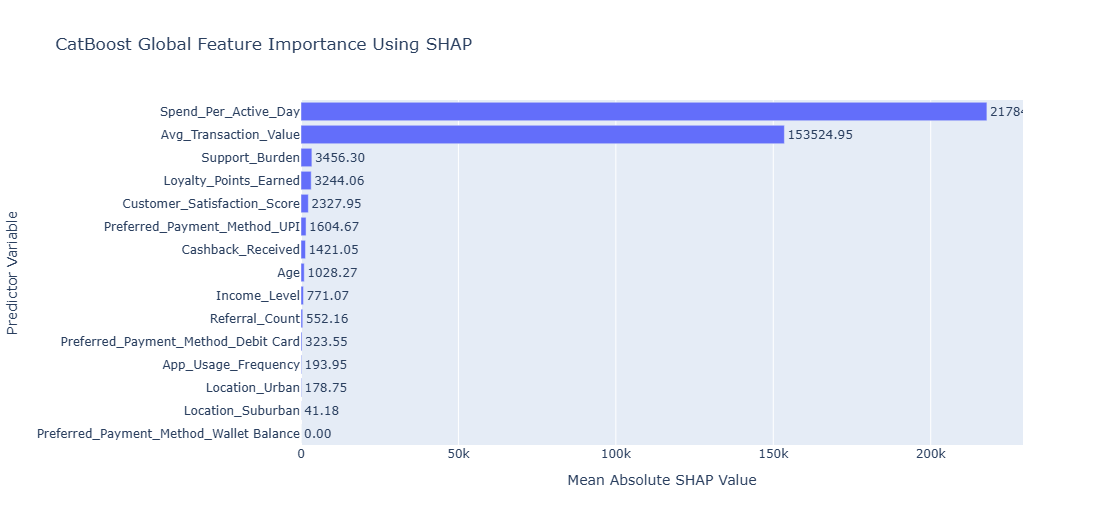


=== TOP 10 CATBOOST FEATURES BASED ON SHAP ===
                     Feature  Mean Absolute SHAP
        Spend_Per_Active_Day         217847.2799
       Avg_Transaction_Value         153524.9477
              Support_Burden           3456.3018
       Loyalty_Points_Earned           3244.0565
 Customer_Satisfaction_Score           2327.9477
Preferred_Payment_Method_UPI           1604.6686
           Cashback_Received           1421.0521
                         Age           1028.2699
                Income_Level            771.0726
              Referral_Count            552.1647


In [12]:
# ======================================================================
# === ML MODELLING_2: SHAP EXPLAINABILITY FOR CATBOOST ================
# ======================================================================


# ======================================================================
# === STEP 1: CREATE SHAP EXPLAINER ===================================
# ======================================================================

# SHAP (SHapley Additive exPlanations) is used to explain how the
# CatBoost model uses the predictor variables to generate LTV
# predictions.
#
# SHAP assigns each feature a contribution value for each observation.
#
# Positive SHAP values indicate that a feature pushes the prediction
# towards a higher LTV.
#
# Negative SHAP values indicate that a feature pushes the prediction
# towards a lower LTV.
#
# For the global feature-importance analysis below, we use the mean
# absolute SHAP value across all observations.
#
# A larger mean absolute SHAP value means that the feature has a
# greater overall influence on the CatBoost predictions.

explainer = shap.TreeExplainer(
    best_catboost_model
)


# ======================================================================
# === STEP 2: CALCULATE SHAP VALUES ===================================
# ======================================================================

# Calculate SHAP values for the independent test dataset.
#
# The test dataset is used because it contains observations that were
# not used to train the final CatBoost model.
#
# This provides an explanation of how the model behaves on unseen
# customer observations.

shap_values = explainer.shap_values(
    X_test
)


# ======================================================================
# === STEP 3: CALCULATE GLOBAL FEATURE IMPORTANCE =====================
# ======================================================================

# Calculate the mean absolute SHAP value for every predictor.
#
# abs(shap_values) removes the direction of the effect and focuses
# only on the magnitude of the contribution.
#
# mean(axis=0) calculates the average contribution of each feature
# across all test observations.
#
# Therefore, this represents the GLOBAL importance of each variable
# to the CatBoost LTV predictions.

mean_abs_shap = np.abs(
    shap_values
).mean(axis=0)


# ======================================================================
# === STEP 4: CREATE SHAP FEATURE-IMPORTANCE DATAFRAME ===============
# ======================================================================

# Create a DataFrame containing each feature and its corresponding
# mean absolute SHAP value.
#
# This makes the results easier to sort, inspect and plot.

shap_importance = pd.DataFrame({

    "Feature": X_test.columns,

    "Mean Absolute SHAP": mean_abs_shap

})


# ======================================================================
# === STEP 5: SORT FEATURES BY SHAP IMPORTANCE ========================
# ======================================================================

# Sort the features from the least important to the most important.
#
# Sorting in ascending order is useful for creating a horizontal
# bar chart where the most important features appear at the top.

shap_importance = shap_importance.sort_values(
    by="Mean Absolute SHAP",
    ascending=True
)


# ======================================================================
# === STEP 6: DISPLAY SHAP FEATURE IMPORTANCE =========================
# ======================================================================

# Display the global SHAP importance values.
#
# The largest values indicate the variables that have the greatest
# influence on the CatBoost model's LTV predictions.

print("\n" + "=" * 80)
print("=== CATBOOST SHAP FEATURE IMPORTANCE ===")
print("=" * 80)

print(
    shap_importance
    .sort_values(
        by="Mean Absolute SHAP",
        ascending=False
    )
    .round(4)
    .to_string(index=False)
)


# ======================================================================
# === STEP 7: HORIZONTAL SHAP FEATURE-IMPORTANCE PLOT =================
# ======================================================================

# Create a horizontal bar chart showing the global importance of
# the variables selected by the CatBoost model.
#
# Horizontal bars make long feature names easier to read.
#
# Features with larger mean absolute SHAP values have a greater
# influence on the model's predictions.
#
# The most influential variables are displayed at the top.

fig = px.bar(
    shap_importance,
    x="Mean Absolute SHAP",
    y="Feature",
    orientation="h",
    title="CatBoost Global Feature Importance Using SHAP",
    labels={
        "Mean Absolute SHAP": "Mean |SHAP Value|",
        "Feature": "Predictor Variable"
    },
    text="Mean Absolute SHAP"
)


# ======================================================================
# === STEP 8: FORMAT SHAP PLOT ========================================
# ======================================================================

# Display the numerical SHAP values at the end of each bar.
#
# This makes it easier to compare the magnitude of feature
# contributions directly from the chart.

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)


# Improve the overall layout so that long feature names and the
# SHAP values remain clearly visible.

fig.update_layout(
    height=max(
        500,
        len(shap_importance) * 35
    ),
    xaxis_title="Mean Absolute SHAP Value",
    yaxis_title="Predictor Variable",
    showlegend=False
)


# Display the horizontal SHAP feature-importance chart.

fig.show()


# ======================================================================
# === STEP 9: IDENTIFY TOP SHAP FEATURES ==============================
# ======================================================================

# Identify the five most influential variables according to their
# mean absolute SHAP values.
#
# These variables can be discussed in the interpretation section
# of the NexaSat Digital Wallet CLV project.

top_shap_features = (
    shap_importance
    .sort_values(
        by="Mean Absolute SHAP",
        ascending=False
    )
    .head(10)
)


print("\n" + "=" * 80)
print("=== TOP 10 CATBOOST FEATURES BASED ON SHAP ===")
print("=" * 80)

print(
    top_shap_features
    .round(4)
    .to_string(index=False)
)


# ======================================================================
# === END OF CATBOOST SHAP EXPLAINABILITY =============================
# ======================================================================

# CatBoost Final Retraining

In [13]:
# ==============================================================================
# === SHAP-BASED CATBOOST FEATURE REDUCTION AND RETRAINING ======================
# === TOP 10 MOST IMPORTANT FEATURES ============================================
# ==============================================================================


# ==============================================================================
# === STEP 1: DEFINE THE SHAP-SELECTED TOP 10 FEATURES =========================
# ==============================================================================

# The initial CatBoost model was previously trained using the predictor
# variables that remained after correlation and VIF-based screening.
#
# SHAP (SHapley Additive exPlanations) was then used to measure the
# contribution of each predictor to the CatBoost model's predictions.
#
# Mean Absolute SHAP represents the average magnitude of a feature's
# contribution across the observations.
#
# A larger Mean Absolute SHAP value indicates that the feature has a
# greater influence on the model's predictions.
#
# The following ten variables were identified as the most important
# features according to the previous CatBoost SHAP analysis.
#
# IMPORTANT:
# These variables are selected from the previously trained CatBoost
# model and are now being used to construct a reduced feature set.
#
# The purpose is to investigate whether a smaller set of the most
# influential variables can achieve predictive performance comparable
# to the original full-feature CatBoost model.

top_10_features = [

    "Spend_Per_Active_Day",
    "Avg_Transaction_Value",
    "Support_Burden",
    "Loyalty_Points_Earned",
    "Customer_Satisfaction_Score",
    "Preferred_Payment_Method_UPI",
    "Cashback_Received",
    "Age",
    "Income_Level",
    "Referral_Count"
]


# ==============================================================================
# === STEP 2: VERIFY SHAP-SELECTED FEATURES ====================================
# ==============================================================================

# Before creating the reduced dataset, verify that every feature selected
# from the SHAP analysis is available in the current training dataset.
#
# This validation step prevents errors caused by:
#
# - misspelled feature names
# - renamed variables
# - variables removed during previous preprocessing
# - inconsistencies between the SHAP analysis and modelling dataset
#
# If a feature is missing, the pipeline stops rather than silently
# continuing with an incomplete feature set.

missing_features = [
    feature
    for feature in top_10_features
    if feature not in X_train.columns
]


print("\n" + "=" * 80)
print("=== SHAP TOP 10 FEATURE VALIDATION ===")
print("=" * 80)


if missing_features:

    print("WARNING: The following SHAP-selected features are missing:")
    print()

    for feature in missing_features:
        print(f"✗ {feature}")

    raise ValueError(
        "One or more SHAP-selected features are not available "
        "in X_train."
    )

else:

    print(
        "✓ All Top 10 SHAP-selected features are available "
        "in the modelling dataset."
    )


# ==============================================================================
# === STEP 3: CREATE THE REDUCED TRAINING AND TEST DATASETS ====================
# ==============================================================================

# Create a reduced version of the training dataset containing only the
# Top 10 SHAP-selected predictors.
#
# X_train contains the complete predictor set surviving the earlier
# preprocessing and feature-screening stages.
#
# X_train_top10 contains only the ten predictors identified as the most
# influential by SHAP.
#
# The same ten variables are selected from X_test.
#
# IMPORTANT:
# The independent test dataset is NOT used to determine the Top 10 features.
#
# The feature-selection decision was made using the previous modelling
# process, while the independent test data remains reserved for final
# evaluation.
#
# This separation helps prevent information leakage into the final
# performance assessment.

X_train_top10 = X_train[
    top_10_features
].copy()


X_test_top10 = X_test[
    top_10_features
].copy()


# ==============================================================================
# === STEP 4: VERIFY REDUCED DATASET ===========================================
# ==============================================================================

# Display the number of predictors before and after SHAP-based reduction.
#
# This provides a transparent record of how much the feature space has
# been reduced.
#
# Reducing the number of predictors can improve:
#
# - model interpretability
# - computational efficiency
# - model simplicity
# - practical deployment
#
# However, feature reduction must not substantially reduce predictive
# performance.

print("\n" + "=" * 80)
print("=== SHAP-BASED FEATURE REDUCTION ===")
print("=" * 80)

print(
    f"Original number of predictors: "
    f"{X_train.shape[1]}"
)

print(
    f"Number of SHAP-selected predictors: "
    f"{len(top_10_features)}"
)

print(
    f"Predictors removed: "
    f"{X_train.shape[1] - len(top_10_features)}"
)


print("\n=== SELECTED TOP 10 FEATURES ===")

for rank, feature in enumerate(
    top_10_features,
    start=1
):

    print(
        f"{rank:>2}. {feature}"
    )


print("\n=== REDUCED DATASET DIMENSIONS ===")

print(
    f"X_train_top10: "
    f"{X_train_top10.shape}"
)

print(
    f"X_test_top10:  "
    f"{X_test_top10.shape}"
)


# ==============================================================================
# === STEP 5: DEFINE THE REDUCED-FEATURE CATBOOST MODEL ========================
# ==============================================================================

# Create a new CatBoost regression model.
#
# This model is trained from scratch using only the Top 10 SHAP-selected
# predictors.
#
# IMPORTANT:
# If CatBoost hyperparameter tuning has already been performed, the
# optimal hyperparameters obtained from that tuning exercise should be
# used here.
#
# The parameters below are placeholders based on the previous CatBoost
# configuration.
#
# For the final dissertation model, replace these values with the
# best-performing parameters from the formal hyperparameter tuning stage.
#
# CatBoost is a gradient boosting algorithm that constructs decision
# trees sequentially.
#
# Each new tree attempts to improve upon the prediction errors made by
# the previous trees.
#
# This makes CatBoost particularly suitable for structured/tabular
# customer analytics data.

catboost_top10 = CatBoostRegressor(

    # Number of boosting iterations/trees.
    iterations=300,

    # Learning rate controls how strongly each new tree contributes
    # to the final prediction.
    learning_rate=0.05,

    # Maximum depth controls the complexity of individual trees.
    depth=6,

    # RMSE is used as the optimisation loss for this regression problem.
    loss_function="RMSE",

    # Ensures reproducible model training.
    random_seed=42,

    # Prevents CatBoost from printing iteration-level training output.
    verbose=False
)


# ==============================================================================
# === STEP 6: TRAIN CATBOOST USING THE TOP 10 FEATURES =========================
# ==============================================================================

# Train the reduced CatBoost model.
#
# Only X_train_top10 and y_train are supplied to the model.
#
# The independent test data is deliberately excluded from model fitting.
#
# The model therefore learns the relationship between the ten selected
# customer characteristics and LTV using only the training observations.

print("\n" + "=" * 80)
print("=== TRAINING CATBOOST USING TOP 10 SHAP FEATURES ===")
print("=" * 80)


catboost_top10.fit(
    X_train_top10,
    y_train
)


print(
    "✓ CatBoost successfully trained using the Top 10 SHAP features."
)


# ==============================================================================
# === STEP 7: GENERATE TRAINING PREDICTIONS ====================================
# ==============================================================================

# Generate predictions for the observations used to train the model.
#
# These predictions allow us to measure how closely the model fits the
# training data.
#
# Training performance alone should NOT be used to select the final model,
# because a complex model may achieve excellent training performance
# while performing poorly on unseen observations.

y_train_pred_top10 = catboost_top10.predict(
    X_train_top10
)


# ==============================================================================
# === STEP 8: GENERATE INDEPENDENT TEST PREDICTIONS ============================
# ==============================================================================

# Generate predictions for the independent test observations.
#
# These observations were not used to train the model.
#
# Consequently, test performance provides an important assessment of
# how well the SHAP-reduced CatBoost model generalises to unseen customers.

y_test_pred_top10 = catboost_top10.predict(
    X_test_top10
)


# ==============================================================================
# === STEP 9: CALCULATE TRAINING MAE ===========================================
# ==============================================================================

# Mean Absolute Error (MAE) measures the average absolute difference
# between actual and predicted LTV.
#
# MAE is expressed in the same units as LTV.
#
# Lower MAE indicates smaller average prediction errors.
#
# Training MAE is useful for assessing model fit but should not be
# considered in isolation when selecting the final model.

train_mae_top10 = mean_absolute_error(
    y_train,
    y_train_pred_top10
)


# ==============================================================================
# === STEP 10: CALCULATE TRAINING RMSE =========================================
# ==============================================================================

# Root Mean Squared Error (RMSE) is calculated by taking the square root
# of the mean squared prediction error.
#
# RMSE gives greater weight to large prediction errors than MAE.
#
# This is particularly relevant for LTV modelling because large errors
# for high-value customers can be important.
#
# Lower RMSE indicates better predictive performance.

train_rmse_top10 = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_top10
    )
)


# ==============================================================================
# === STEP 11: CALCULATE TRAINING MAPE =========================================
# ==============================================================================

# Mean Absolute Percentage Error (MAPE) expresses the average prediction
# error as a percentage of the actual LTV.
#
# The result is multiplied by 100 to convert the proportion into a
# percentage.
#
# MAPE should be interpreted cautiously when the target contains zero
# or very small values.

train_mape_top10 = (
    mean_absolute_percentage_error(
        y_train,
        y_train_pred_top10
    ) * 100
)


# ==============================================================================
# === STEP 12: CALCULATE TRAINING R² ===========================================
# ==============================================================================

# R² measures the proportion of variation in LTV explained by the
# predictors included in the model.
#
# An R² closer to 1 indicates stronger explanatory performance.
#
# However, training R² can be overly optimistic because the model has
# already seen these observations.

train_r2_top10 = r2_score(
    y_train,
    y_train_pred_top10
)


# ==============================================================================
# === STEP 13: CALCULATE TRAINING ADJUSTED R² ================================
# ==============================================================================

# Determine the number of training observations.

n_train_top10 = X_train_top10.shape[0]


# Determine the number of predictors used by the reduced model.
#
# In this case, p = 10.

p_top10 = X_train_top10.shape[1]


# Adjusted R² accounts for the number of predictors in the model.
#
# Unlike ordinary R², Adjusted R² applies a penalty for additional
# predictors that do not provide sufficient explanatory improvement.
#
# This is useful when comparing the original CatBoost model with the
# SHAP-reduced model because the reduced model uses fewer variables.

train_adjusted_r2_top10 = adjusted_r2(
    train_r2_top10,
    n_train_top10,
    p_top10
)


# ==============================================================================
# === STEP 14: CALCULATE INDEPENDENT TEST MAE ================================
# ==============================================================================

# Calculate MAE using the independent test observations.
#
# This represents the average absolute prediction error when the
# SHAP-reduced CatBoost model is applied to unseen customers.

test_mae_top10 = mean_absolute_error(
    y_test,
    y_test_pred_top10
)


# ==============================================================================
# === STEP 15: CALCULATE INDEPENDENT TEST RMSE ================================
# ==============================================================================

# Calculate RMSE using the independent test predictions.
#
# Lower test RMSE indicates better predictive accuracy on unseen
# observations.

test_rmse_top10 = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_top10
    )
)


# ==============================================================================
# === STEP 16: CALCULATE INDEPENDENT TEST MAPE ================================
# ==============================================================================

# Calculate MAPE on the independent test observations.

test_mape_top10 = (
    mean_absolute_percentage_error(
        y_test,
        y_test_pred_top10
    ) * 100
)


# ==============================================================================
# === STEP 17: CALCULATE INDEPENDENT TEST R² ==================================
# ==============================================================================

# Test R² measures how much of the variation in unseen LTV observations
# is explained by the SHAP-reduced model.
#
# This is one of the most important metrics when comparing the reduced
# model with the original CatBoost model.

test_r2_top10 = r2_score(
    y_test,
    y_test_pred_top10
)


# ==============================================================================
# === STEP 18: CALCULATE TEST ADJUSTED R² ======================================
# ==============================================================================

# Determine the number of observations in the independent test dataset.

n_test_top10 = X_test_top10.shape[0]


# Calculate Adjusted R² using the test R² and the number of predictors.
#
# Because the reduced model contains only ten predictors, the Adjusted
# R² penalty is smaller than it would be for a larger feature set,
# provided the predictors contribute useful explanatory information.

test_adjusted_r2_top10 = adjusted_r2(
    test_r2_top10,
    n_test_top10,
    p_top10
)


# ==============================================================================
# === STEP 19: CALCULATE GENERALISATION GAPS ==================================
# ==============================================================================

# Calculate the difference between training and test R².
#
# Formula:
#
# R² Gap = Training R² - Test R²
#
# A large positive gap indicates that the model performs considerably
# better on training observations than unseen observations.
#
# This can be evidence of overfitting.
#
# A smaller gap generally indicates better generalisation.

r2_gap_top10 = (
    train_r2_top10
    - test_r2_top10
)


# Calculate the difference between training and test Adjusted R².

adjusted_r2_gap_top10 = (
    train_adjusted_r2_top10
    - test_adjusted_r2_top10
)


# ==============================================================================
# === STEP 20: FIVE-FOLD CROSS-VALIDATION =====================================
# ==============================================================================

# Five-fold cross-validation is used to assess the stability of the
# SHAP-reduced CatBoost model.
#
# The training dataset is divided into five folds.
#
# For each iteration:
#
# - Four folds are used to train the model.
# - One fold is used to validate the model.
# - The process is repeated until every fold has been used for validation.
#
# This provides five independent validation estimates.
#
# Importantly, the independent test set is NOT involved in this process.
#
# This allows cross-validation to assess generalisation during model
# development without contaminating the final test evaluation.

print("\n" + "=" * 80)
print("=== FIVE-FOLD CROSS-VALIDATION ===")
print("=" * 80)


# ==============================================================================
# === STEP 21: CROSS-VALIDATION MAE ===========================================
# ==============================================================================

# Calculate MAE for each of the five validation folds.
#
# scikit-learn returns negative MAE because its scoring framework assumes
# that larger scores represent better performance.
#
# The negative sign converts the scores back to conventional positive
# MAE values.
#
# The mean represents average validation performance.
#
# The standard deviation measures variation in performance across folds.

cv_mae_top10 = -cross_val_score(
    catboost_top10,
    X_train_top10,
    y_train,
    cv=cv,
    scoring="neg_mean_absolute_error"
)


cv_mae_mean_top10 = cv_mae_top10.mean()

cv_mae_std_top10 = cv_mae_top10.std()


# ==============================================================================
# === STEP 22: CROSS-VALIDATION RMSE ===========================================
# ==============================================================================

# Calculate negative MSE for each validation fold.

cv_mse_top10 = -cross_val_score(
    catboost_top10,
    X_train_top10,
    y_train,
    cv=cv,
    scoring="neg_mean_squared_error"
)


# Convert MSE into RMSE.
#
# RMSE is easier to interpret because it is expressed in the same
# units as LTV.

cv_rmse_top10 = np.sqrt(
    cv_mse_top10
)


cv_rmse_mean_top10 = cv_rmse_top10.mean()

cv_rmse_std_top10 = cv_rmse_top10.std()


# ==============================================================================
# === STEP 23: CROSS-VALIDATION MAPE ==========================================
# ==============================================================================

# Calculate MAPE across the five validation folds.

cv_mape_top10 = -cross_val_score(
    catboost_top10,
    X_train_top10,
    y_train,
    cv=cv,
    scoring="neg_mean_absolute_percentage_error"
)


# Convert MAPE from a proportion to a percentage.

cv_mape_top10 = (
    cv_mape_top10 * 100
)


cv_mape_mean_top10 = cv_mape_top10.mean()

cv_mape_std_top10 = cv_mape_top10.std()


# ==============================================================================
# === STEP 24: CROSS-VALIDATION R² ============================================
# ==============================================================================

# Calculate R² for each of the five validation folds.
#
# Higher R² indicates stronger predictive performance.
#
# The mean CV R² provides an estimate of expected generalisation
# performance across different samples of the training dataset.

cv_r2_top10 = cross_val_score(
    catboost_top10,
    X_train_top10,
    y_train,
    cv=cv,
    scoring="r2"
)


# Calculate the average R² across the five folds.

cv_r2_mean_top10 = cv_r2_top10.mean()


# Calculate the standard deviation of R² across the five folds.
#
# A smaller standard deviation indicates that model performance is
# relatively stable across different validation samples.

cv_r2_std_top10 = cv_r2_top10.std()


# ==============================================================================
# === STEP 25: CREATE MODEL PERFORMANCE TABLE ================================
# ==============================================================================

# Store all performance metrics in a single DataFrame.
#
# This makes the SHAP-reduced CatBoost model easy to compare against
# the original full-feature CatBoost model.
#
# The comparison should focus particularly on:
#
# - CV R²
# - CV RMSE
# - Test R²
# - Test RMSE
# - Test MAE
# - R² generalisation gap
#
# A reduced model is desirable if it retains similar predictive
# performance while using substantially fewer predictors.

catboost_top10_results = pd.DataFrame({

    "Model": [
        "CatBoost - Top 10 SHAP Features"
    ],

    "Features": [
        len(top_10_features)
    ],

    "Train MAE": [
        train_mae_top10
    ],

    "Train RMSE": [
        train_rmse_top10
    ],

    "Train MAPE (%)": [
        train_mape_top10
    ],

    "Train R²": [
        train_r2_top10
    ],

    "Train Adjusted R²": [
        train_adjusted_r2_top10
    ],

    "Test MAE": [
        test_mae_top10
    ],

    "Test RMSE": [
        test_rmse_top10
    ],

    "Test MAPE (%)": [
        test_mape_top10
    ],

    "Test R²": [
        test_r2_top10
    ],

    "Test Adjusted R²": [
        test_adjusted_r2_top10
    ],

    "CV MAE Mean": [
        cv_mae_mean_top10
    ],

    "CV MAE Std": [
        cv_mae_std_top10
    ],

    "CV RMSE Mean": [
        cv_rmse_mean_top10
    ],

    "CV RMSE Std": [
        cv_rmse_std_top10
    ],

    "CV MAPE Mean (%)": [
        cv_mape_mean_top10
    ],

    "CV MAPE Std (%)": [
        cv_mape_std_top10
    ],

    "CV R² Mean": [
        cv_r2_mean_top10
    ],

    "CV R² Std": [
        cv_r2_std_top10
    ],

    "R² Gap": [
        r2_gap_top10
    ],

    "Adjusted R² Gap": [
        adjusted_r2_gap_top10
    ]
})


# ==============================================================================
# === STEP 26: DISPLAY MODEL PERFORMANCE =====================================
# ==============================================================================

# Display the complete performance results for the SHAP-reduced CatBoost.
#
# The results can subsequently be compared against the performance of
# the original full-feature CatBoost.

print("\n" + "=" * 120)
print("=== CATBOOST PERFORMANCE USING TOP 10 SHAP FEATURES ===")
print("=" * 120)

print(
    catboost_top10_results
    .round(4)
    .to_string(index=False)
)


# ==============================================================================
# === STEP 27: DISPLAY CROSS-VALIDATION STABILITY ============================
# ==============================================================================

# Display the average cross-validation performance and its standard
# deviation.
#
# The standard deviation is important because two models with similar
# average CV performance may have different levels of stability.
#
# Lower variability generally indicates more consistent performance
# across different validation folds.

print("\n" + "=" * 90)
print("=== TOP 10 CATBOOST CROSS-VALIDATION STABILITY ===")
print("=" * 90)


print(
    f"CV MAE:  "
    f"{cv_mae_mean_top10:.4f} "
    f"+/- {cv_mae_std_top10:.4f}"
)


print(
    f"CV RMSE: "
    f"{cv_rmse_mean_top10:.4f} "
    f"+/- {cv_rmse_std_top10:.4f}"
)


print(
    f"CV MAPE: "
    f"{cv_mape_mean_top10:.2f}% "
    f"+/- {cv_mape_std_top10:.2f}%"
)


print(
    f"CV R²:   "
    f"{cv_r2_mean_top10:.4f} "
    f"+/- {cv_r2_std_top10:.4f}"
)


# ==============================================================================
# === STEP 28: GENERALISATION AND OVERFITTING DIAGNOSTIC ======================
# ==============================================================================

# Compare training and independent test performance.
#
# The purpose is to determine whether reducing the feature set has
# affected the model's ability to generalise.
#
# A small R² gap suggests that training and test performance are
# relatively similar.
#
# A large positive gap suggests that the model fits the training data
# substantially better than the unseen test data.

print("\n" + "=" * 90)
print("=== TOP 10 CATBOOST GENERALISATION DIAGNOSTIC ===")
print("=" * 90)


print(
    f"Train R²:           "
    f"{train_r2_top10:.4f}"
)


print(
    f"Test R²:            "
    f"{test_r2_top10:.4f}"
)


print(
    f"R² Gap:             "
    f"{r2_gap_top10:.4f}"
)


print(
    f"Train Adjusted R²:  "
    f"{train_adjusted_r2_top10:.4f}"
)


print(
    f"Test Adjusted R²:   "
    f"{test_adjusted_r2_top10:.4f}"
)


print(
    f"Adjusted R² Gap:    "
    f"{adjusted_r2_gap_top10:.4f}"
)


# ==============================================================================
# === STEP 29: DISPLAY SHAP-SELECTED VARIABLES ================================
# ==============================================================================

# Display the final feature set used by the reduced CatBoost model.
#
# This provides an explicit record of the variables retained after
# SHAP-based feature selection.

print("\n" + "=" * 80)
print("=== FINAL SHAP-SELECTED FEATURE SET ===")
print("=" * 80)


for rank, feature in enumerate(
    top_10_features,
    start=1
):

    print(
        f"{rank:>2}. {feature}"
    )


# ==============================================================================
# === STEP 30: FINAL SHAP-REDUCED CATBOOST SUMMARY ============================
# ==============================================================================

# Provide a concise summary of the complete modelling process.
#
# This confirms that the model has:
#
# - been retrained using the Top 10 SHAP features
# - been evaluated on unseen test observations
# - been evaluated using five-fold cross-validation
# - been assessed using multiple regression metrics
# - been assessed for potential overfitting
#
# The resulting model can now be compared directly against the original
# full-feature CatBoost model.

print("\n" + "=" * 90)
print("=== SHAP-BASED CATBOOST RETRAINING SUMMARY ===")
print("=" * 90)


print(
    f"✓ Original predictor count: "
    f"{X_train.shape[1]}"
)


print(
    f"✓ SHAP-selected predictor count: "
    f"{len(top_10_features)}"
)


print("✓ CatBoost retrained using the Top 10 SHAP features.")

print("✓ Training predictions generated.")

print("✓ Independent test predictions generated.")

print("✓ MAE calculated.")

print("✓ RMSE calculated.")

print("✓ MAPE calculated.")

print("✓ R² calculated.")

print("✓ Adjusted R² calculated.")

print("✓ Five-fold cross-validation performed.")

print("✓ Cross-validation MAE calculated.")

print("✓ Cross-validation RMSE calculated.")

print("✓ Cross-validation MAPE calculated.")

print("✓ Cross-validation R² calculated.")

print("✓ Cross-validation variability calculated.")

print("✓ R² generalisation gap calculated.")

print("✓ Adjusted R² generalisation gap calculated.")


# ==============================================================================
# === STEP 31: END OF SHAP-BASED CATBOOST PIPELINE ============================
# ==============================================================================

print("\n" + "=" * 90)
print("=== END OF SHAP-BASED CATBOOST RETRAINING ===")
print("=" * 90)


=== SHAP TOP 10 FEATURE VALIDATION ===
✓ All Top 10 SHAP-selected features are available in the modelling dataset.

=== SHAP-BASED FEATURE REDUCTION ===
Original number of predictors: 15
Number of SHAP-selected predictors: 10
Predictors removed: 5

=== SELECTED TOP 10 FEATURES ===
 1. Spend_Per_Active_Day
 2. Avg_Transaction_Value
 3. Support_Burden
 4. Loyalty_Points_Earned
 5. Customer_Satisfaction_Score
 6. Preferred_Payment_Method_UPI
 7. Cashback_Received
 8. Age
 9. Income_Level
10. Referral_Count

=== REDUCED DATASET DIMENSIONS ===
X_train_top10: (5600, 10)
X_test_top10:  (1400, 10)

=== TRAINING CATBOOST USING TOP 10 SHAP FEATURES ===
✓ CatBoost successfully trained using the Top 10 SHAP features.

=== FIVE-FOLD CROSS-VALIDATION ===

=== CATBOOST PERFORMANCE USING TOP 10 SHAP FEATURES ===
                          Model  Features   Train MAE  Train RMSE  Train MAPE (%)  Train R²  Train Adjusted R²    Test MAE   Test RMSE  Test MAPE (%)  Test R²  Test Adjusted R²  CV MAE Mean  

# Final SHAP Feature Intepretation


=== FINAL SHAP VALUES ===
Number of customers explained: 1400
Number of features explained: 10

=== FINAL CATBOOST SHAP FEATURE IMPORTANCE ===
                     Feature  Mean Absolute SHAP
        Spend_Per_Active_Day         221994.2684
       Avg_Transaction_Value         153231.3602
              Support_Burden           6398.7555
       Loyalty_Points_Earned           5722.7046
Preferred_Payment_Method_UPI           4661.7081
 Customer_Satisfaction_Score           4641.3078
           Cashback_Received           4440.9170
                         Age           4423.9993
                Income_Level           3436.4868
              Referral_Count           3096.2530


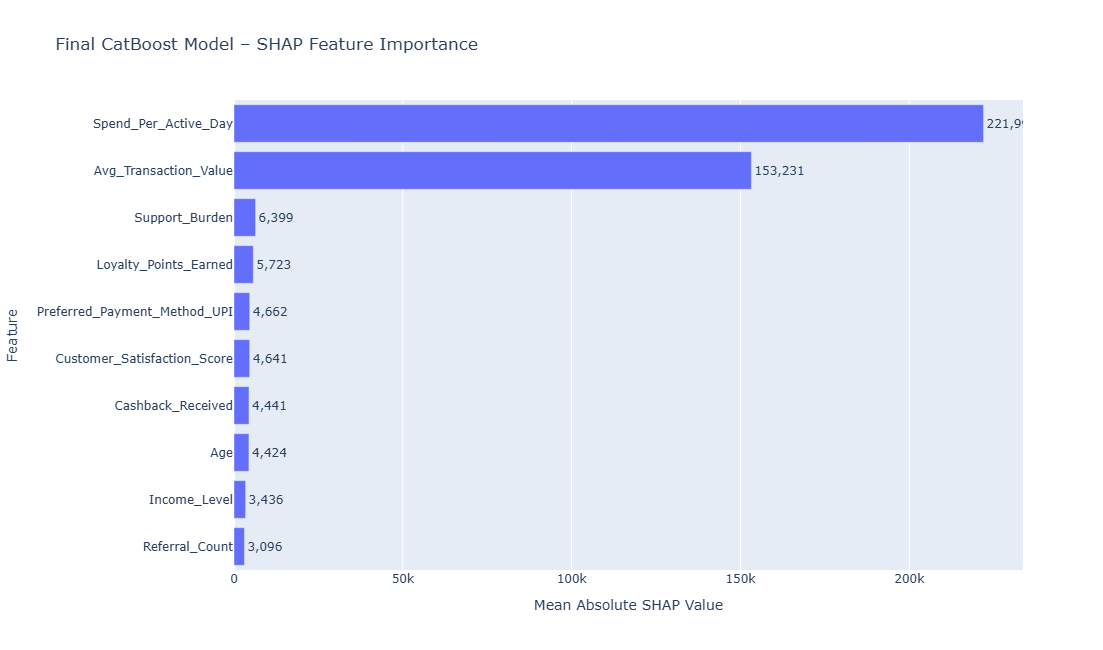

In [17]:
# ======================================================================
# === FINAL SHAP INTERPRETATION USING PLOTLY ===========================
# === FINAL CATBOOST MODEL WITH TOP 10 FEATURES ========================
# ======================================================================


# ======================================================================
# === STEP 1: PREPARE DATA FOR SHAP ANALYSIS ==========================
# ======================================================================

# The final CatBoost model was trained using the ten features selected
# from the previous SHAP feature-selection stage.
#
# We use the independent test dataset for the final interpretation
# because these observations were not used to train the model.
#
# This allows us to understand how the final model behaves when
# predicting unseen customer observations.

X_test_shap = X_test[
    top_10_features
].copy()


# ======================================================================
# === STEP 2: CREATE SHAP EXPLAINER ===================================
# ======================================================================

# TreeExplainer is specifically designed for tree-based models.
#
# CatBoost is a tree-based gradient boosting algorithm, so SHAP can
# efficiently calculate the contribution of each predictor to the
# model's LTV predictions.

explainer = shap.TreeExplainer(
    catboost_top10_model
)


# ======================================================================
# === STEP 3: CALCULATE SHAP VALUES ===================================
# ======================================================================

# Calculate SHAP values for every customer in the independent
# test dataset.
#
# Each row represents one customer.
#
# Each column represents one predictor.
#
# A positive SHAP value means that the feature pushes the predicted
# LTV higher for that customer.
#
# A negative SHAP value means that the feature pushes the predicted
# LTV lower for that customer.

shap_values = explainer.shap_values(
    X_test_shap
)


print("\n" + "=" * 80)
print("=== FINAL SHAP VALUES ===")
print("=" * 80)

print(
    f"Number of customers explained: {X_test_shap.shape[0]}"
)

print(
    f"Number of features explained: {X_test_shap.shape[1]}"
)


# ======================================================================
# === STEP 4: CALCULATE GLOBAL SHAP IMPORTANCE ========================
# ======================================================================

# Mean Absolute SHAP measures the average magnitude of each feature's
# contribution to the model predictions.
#
# Taking the absolute value prevents positive and negative contributions
# from cancelling each other out.
#
# Therefore:
#
# Larger Mean Absolute SHAP
#     = greater overall model influence
#
# Smaller Mean Absolute SHAP
#     = lower overall model influence

mean_abs_shap = np.abs(
    shap_values
).mean(
    axis=0
)


# Create a DataFrame containing the global SHAP importance.

shap_importance = pd.DataFrame({

    "Feature": X_test_shap.columns,

    "Mean Absolute SHAP": mean_abs_shap

})


# Sort from most important to least important.

shap_importance = (
    shap_importance
    .sort_values(
        "Mean Absolute SHAP",
        ascending=True
    )
    .reset_index(drop=True)
)


# ======================================================================
# === STEP 5: DISPLAY SHAP IMPORTANCE TABLE ===========================
# ======================================================================

print("\n" + "=" * 90)
print("=== FINAL CATBOOST SHAP FEATURE IMPORTANCE ===")
print("=" * 90)

print(
    shap_importance
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False
    )
    .round(4)
    .to_string(index=False)
)


# ======================================================================
# === STEP 6: CREATE INTERACTIVE HORIZONTAL SHAP BAR CHART ============
# ======================================================================

# Plotly is used to create an interactive horizontal bar chart.
#
# Horizontal bars are useful because several of the feature names are
# relatively long.
#
# The chart ranks variables according to their global contribution
# to the final CatBoost model.
#
# Hovering over a bar displays the exact SHAP importance value.

fig = px.bar(
    shap_importance,
    x="Mean Absolute SHAP",
    y="Feature",
    orientation="h",
    title="Final CatBoost Model – SHAP Feature Importance",
    labels={
        "Mean Absolute SHAP": "Mean Absolute SHAP Value",
        "Feature": "Feature"
    },
    text="Mean Absolute SHAP"
)


# Format the values displayed directly on the bars.

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside"
)


# Improve the overall layout.

fig.update_layout(
    height=650,
    width=1000,
    yaxis={
        "categoryorder": "total ascending"
    },
    hovermode="y unified"
)


# Display the interactive Plotly chart.

fig.show()

# Save Final Model 

In [20]:
# ======================================================================
# === STEP 1: IMPORT JOBLIB ============================================
# ======================================================================

# joblib is used to serialise and save Python machine-learning objects.
#
# Saving the trained model allows us to reload it later without
# retraining the CatBoost model from scratch.

import joblib


# ======================================================================
# === STEP 2: DEFINE FINAL MODEL ======================================
# ======================================================================

# The final model should be the CatBoost model retrained using the
# Top 10 features identified through SHAP feature importance.
#
# IMPORTANT:
# Replace "catboost_top10_model" below with the actual variable name
# of your retrained final CatBoost model if it is different.

final_model = catboost_top10_model


# ======================================================================
# === STEP 3: DEFINE FINAL FEATURE SET ================================
# ======================================================================

# These are the Top 10 features selected using mean absolute SHAP
# importance from the CatBoost model.
#
# The order is preserved so that the same feature structure can be
# used when making future predictions.

final_features = [
    "Spend_Per_Active_Day",
    "Avg_Transaction_Value",
    "Support_Burden",
    "Loyalty_Points_Earned",
    "Customer_Satisfaction_Score",
    "Preferred_Payment_Method_UPI",
    "Cashback_Received",
    "Age",
    "Income_Level",
    "Referral_Count"
]


# ======================================================================
# === STEP 4: SAVE FINAL CATBOOST MODEL ================================
# ======================================================================

# Save the trained CatBoost model to a file.
#
# The .pkl file contains the fitted model, including its learned
# parameters and tree structure.
#
# This allows the model to be loaded later for prediction without
# retraining.

joblib.dump(
    final_model,
    "final_catboost_ltv_model.pkl"
)


# ======================================================================
# === STEP 5: SAVE FINAL FEATURE LIST =================================
# ======================================================================

# Save the final feature list separately.
#
# This is important because the model expects exactly these predictors
# when making future LTV predictions.
#
# Keeping the feature list separately also documents the final
# feature-selection stage of the modelling pipeline.

joblib.dump(
    final_features,
    "final_catboost_ltv_features.pkl"
)


# ======================================================================
# === STEP 6: SAVE MODEL METADATA =====================================
# ======================================================================

# Store important information about the final modelling configuration.
#
# This provides a simple model-development record and makes it easier
# to reproduce the modelling process later.

model_metadata = {

    "model": "CatBoost Regressor",

    "target": "LTV",

    "feature_selection": "Top 10 features based on mean absolute SHAP importance",

    "number_of_features": len(final_features),

    "features": final_features,

    "random_seed": 42
}


# Save the metadata.

joblib.dump(
    model_metadata,
    "final_catboost_ltv_metadata.pkl"
)


# ======================================================================
# === STEP 7: VERIFY SAVED FILES ======================================
# ======================================================================

# Confirm that the model, feature list and metadata have been saved.

print("\n" + "=" * 80)
print("=== FINAL MODEL SAVING SUMMARY ===")
print("=" * 80)

print("✓ Final CatBoost LTV model saved.")
print("✓ Final SHAP-selected feature list saved.")
print("✓ Final model metadata saved.")

print("\nSaved files:")
print("1. final_catboost_ltv_model.pkl")
print("2. final_catboost_ltv_features.pkl")
print("3. final_catboost_ltv_metadata.pkl")

print("\nFinal number of features:", len(final_features))
print("Final target:", "LTV")


# ======================================================================
# === STEP 8: VERIFY MODEL CAN BE RELOADED =============================
# ======================================================================

# Reload the saved model to confirm that the saved file is valid.
#
# This provides an additional check that the model can be successfully
# restored for future prediction.

loaded_model = joblib.load(
    "final_catboost_ltv_model.pkl"
)

loaded_features = joblib.load(
    "final_catboost_ltv_features.pkl"
)


# Confirm successful loading.

print("\n" + "=" * 80)
print("=== SAVED MODEL VERIFICATION ===")
print("=" * 80)

print("✓ Final CatBoost model successfully reloaded.")
print("✓ Final feature list successfully reloaded.")

print("\nReloaded features:")

for i, feature in enumerate(
    loaded_features,
    start=1
):

    print(f"{i:2}. {feature}")


# ======================================================================
# === END OF FINAL MODEL SAVING ========================================
# ======================================================================


=== FINAL MODEL SAVING SUMMARY ===
✓ Final CatBoost LTV model saved.
✓ Final SHAP-selected feature list saved.
✓ Final model metadata saved.

Saved files:
1. final_catboost_ltv_model.pkl
2. final_catboost_ltv_features.pkl
3. final_catboost_ltv_metadata.pkl

Final number of features: 10
Final target: LTV

=== SAVED MODEL VERIFICATION ===
✓ Final CatBoost model successfully reloaded.
✓ Final feature list successfully reloaded.

Reloaded features:
 1. Spend_Per_Active_Day
 2. Avg_Transaction_Value
 3. Support_Burden
 4. Loyalty_Points_Earned
 5. Customer_Satisfaction_Score
 6. Preferred_Payment_Method_UPI
 7. Cashback_Received
 8. Age
 9. Income_Level
10. Referral_Count


# Saved KPI's for DashBoard

In [21]:
# ======================================================================
# === FINAL CATBOOST METRICS + PREDICTIONS + SHAP DATASET =============
# === ONE COMBINED DATAFRAME FOR POWER BI ==============================
# ======================================================================


# ======================================================================
# === STEP 1: CREATE THE BASE CUSTOMER-LEVEL DATAFRAME ================
# ======================================================================

# Start with the test dataset containing the final Top 10 features
# selected using SHAP.
#
# Each row represents one customer from the independent test dataset.
#
# Using X_test_shap ensures that the final dashboard is based on the
# same observations used to evaluate the final CatBoost model.

metrics_df = X_test_shap.copy()


# ======================================================================
# === STEP 2: ADD CUSTOMER IDENTIFIER ==================================
# ======================================================================

# Customer_ID is important for the Power BI dashboard because it allows
# individual customers to be identified and their predicted LTV,
# actual LTV, prediction errors and SHAP explanations to be analysed.
#
# X_test_shap retains the original dataframe index, so we use that index
# to retrieve the corresponding Customer_ID from the original dataset.

if "Customer_ID" in df.columns:

    metrics_df.insert(
        0,
        "Customer_ID",
        df.loc[
            X_test_shap.index,
            "Customer_ID"
        ].values
    )


# ======================================================================
# === STEP 3: GENERATE FINAL CATBOOST PREDICTIONS ======================
# ======================================================================

# Use the final CatBoost model, which was retrained using the Top 10
# SHAP-selected features, to predict Customer Lifetime Value.
#
# These predictions represent the model's estimated LTV for each
# individual customer in the independent test dataset.

metrics_df["Predicted_LTV"] = (
    catboost_top10_model.predict(
        X_test_shap
    )
)


# ======================================================================
# === STEP 4: ADD ACTUAL CUSTOMER LTV ==================================
# ======================================================================

# Add the actual observed LTV for each customer.
#
# This allows the dashboard to compare:
#
#     Actual LTV
#           vs
#     Predicted LTV
#
# and evaluate how accurately the model predicts individual customers.

metrics_df["Actual_LTV"] = (
    y_test.loc[
        X_test_shap.index
    ].values
)


# ======================================================================
# === STEP 5: CALCULATE SIGNED PREDICTION ERROR ========================
# ======================================================================

# Calculate the difference between predicted and actual LTV.
#
# Formula:
#
# Prediction Error =
#     Predicted LTV - Actual LTV
#
# Interpretation:
#
# Positive value:
#     The model overestimated the customer's LTV.
#
# Negative value:
#     The model underestimated the customer's LTV.
#
# A value close to zero indicates that the prediction is close to
# the actual customer LTV.

metrics_df["Prediction_Error"] = (
    metrics_df["Predicted_LTV"]
    - metrics_df["Actual_LTV"]
)


# ======================================================================
# === STEP 6: CALCULATE ABSOLUTE PREDICTION ERROR ======================
# ======================================================================

# Calculate the absolute prediction error.
#
# This removes the direction of the error and measures only its
# magnitude.
#
# For example:
#
# Prediction Error = -50,000
# Absolute Error   =  50,000
#
# This metric is particularly useful for identifying customers for
# whom the model has made large prediction errors.

metrics_df["Absolute_Error"] = (
    metrics_df["Prediction_Error"].abs()
)


# ======================================================================
# === STEP 7: CALCULATE CUSTOMER-LEVEL PERCENTAGE ERROR ===============
# ======================================================================

# Calculate the prediction error as a percentage of actual LTV.
#
# Formula:
#
# Percentage Error =
#     Absolute Error / |Actual LTV| × 100
#
# Zero actual LTV values are replaced with NaN because percentage
# error cannot be calculated when the denominator is zero.

actual_ltv_safe = (
    metrics_df["Actual_LTV"]
    .replace(0, np.nan)
)


metrics_df["Percentage_Error"] = (
    metrics_df["Absolute_Error"]
    /
    actual_ltv_safe.abs()
) * 100


# ======================================================================
# === STEP 8: CREATE SHAP EXPLAINER ====================================
# ======================================================================

# TreeExplainer is specifically designed to explain tree-based
# machine-learning models such as CatBoost.
#
# The explainer determines how much each feature contributed to the
# prediction for each individual customer.
#
# This provides local/customer-level model explainability.

final_explainer = shap.TreeExplainer(
    catboost_top10_model
)


# ======================================================================
# === STEP 9: CALCULATE CUSTOMER-LEVEL SHAP VALUES =====================
# ======================================================================

# Calculate SHAP values for every customer in the independent test
# dataset.
#
# Each SHAP value represents the contribution of one feature to that
# customer's predicted LTV.
#
# Positive SHAP value:
#     Feature pushes predicted LTV upward.
#
# Negative SHAP value:
#     Feature pushes predicted LTV downward.
#
# Larger absolute SHAP value:
#     Greater influence on that customer's prediction.

final_shap_values = (
    final_explainer.shap_values(
        X_test_shap
    )
)


# ======================================================================
# === STEP 10: CONVERT SHAP VALUES INTO A DATAFRAME ===================
# ======================================================================

# Convert the SHAP values into a pandas DataFrame.
#
# Prefixing each column with "SHAP_" makes the columns easy to identify
# later in Power BI.

shap_df = pd.DataFrame(
    final_shap_values,

    columns=[
        f"SHAP_{feature}"
        for feature in top_10_features
    ],

    index=X_test_shap.index
)


# ======================================================================
# === STEP 11: COMBINE SHAP VALUES WITH CUSTOMER DATA =================
# ======================================================================

# Add the individual customer SHAP values to the main metrics dataframe.
#
# The result means that every customer will have:
#
# - their original Top 10 features
# - actual LTV
# - predicted LTV
# - prediction errors
# - SHAP contribution of every Top 10 feature

metrics_df = pd.concat(
    [
        metrics_df,
        shap_df
    ],
    axis=1
)


# ======================================================================
# === STEP 12: CALCULATE GLOBAL SHAP FEATURE IMPORTANCE ===============
# ======================================================================

# Calculate the mean absolute SHAP value for every feature.
#
# This provides a global measure of feature importance across the
# complete test dataset.
#
# Mean absolute SHAP is used because:
#
# - positive and negative SHAP values can cancel each other out
# - taking the absolute value measures the magnitude of influence
# - averaging across customers provides overall feature importance
#
# This is the information used to identify the most influential
# variables in the CatBoost model.

mean_abs_shap = (
    np.abs(final_shap_values)
    .mean(axis=0)
)


# Create a dictionary connecting each feature to its global SHAP
# importance value.

shap_importance_dict = dict(
    zip(
        top_10_features,
        mean_abs_shap
    )
)


# ======================================================================
# === STEP 13: ADD GLOBAL SHAP IMPORTANCE =============================
# ======================================================================

# Add the global SHAP importance for each of the Top 10 features.
#
# These values are model-level statistics rather than customer-level
# statistics.
#
# Therefore, the same global importance value will appear on each
# customer row.
#
# This allows the same CSV file to be used in Power BI while still
# retaining the global feature-importance information.

for feature in top_10_features:

    metrics_df[
        f"SHAP_Importance_{feature}"
    ] = shap_importance_dict[feature]


# ======================================================================
# === STEP 14: CALCULATE CATBOOST BUILT-IN FEATURE IMPORTANCE =========
# ======================================================================

# CatBoost also provides its own built-in feature importance measure.
#
# This is different from SHAP:
#
# SHAP importance:
#     Measures average contribution of features to predictions.
#
# CatBoost feature importance:
#     Measures feature importance according to CatBoost's internal
#     model-based importance calculation.
#
# Both can be useful for understanding the final model.

catboost_importance = (
    catboost_top10_model.get_feature_importance()
)


# Create a dictionary mapping each feature to its CatBoost importance.

catboost_importance_dict = dict(
    zip(
        top_10_features,
        catboost_importance
    )
)


# ======================================================================
# === STEP 15: ADD CATBOOST FEATURE IMPORTANCE ========================
# ======================================================================

# Add CatBoost's global feature importance values to the dataframe.
#
# Again, these values are model-level values and will therefore be
# repeated for every customer.

for feature in top_10_features:

    metrics_df[
        f"CatBoost_Importance_{feature}"
    ] = catboost_importance_dict[feature]


# ======================================================================
# === STEP 16: ADD FINAL TEST PERFORMANCE METRICS =====================
# ======================================================================

# Add the performance of the final CatBoost model on the independent
# test dataset.
#
# These metrics measure how accurately the model predicts unseen
# customer LTV.
#
# R²:
#     Proportion of variation in LTV explained by the model.
#
# Adjusted R²:
#     R² adjusted for the number of predictors.
#
# RMSE:
#     Penalises larger prediction errors more heavily.
#
# MAE:
#     Average absolute prediction error.
#
# MAPE:
#     Average percentage prediction error.

metrics_df["Test_R2"] = test_r2

metrics_df["Test_Adjusted_R2"] = (
    test_adjusted_r2
)

metrics_df["Test_RMSE"] = test_rmse

metrics_df["Test_MAE"] = test_mae

metrics_df["Test_MAPE"] = test_mape


# ======================================================================
# === STEP 17: ADD TRAINING PERFORMANCE METRICS =======================
# ======================================================================

# Store the training performance of the final CatBoost model.
#
# Comparing training and test performance allows us to assess whether
# the model may be overfitting the training data.

metrics_df["Train_R2"] = train_r2

metrics_df["Train_Adjusted_R2"] = (
    train_adjusted_r2
)

metrics_df["Train_RMSE"] = train_rmse

metrics_df["Train_MAE"] = train_mae

metrics_df["Train_MAPE"] = train_mape


# ======================================================================
# === STEP 18: ADD CROSS-VALIDATION PERFORMANCE =======================
# ======================================================================

# Add the five-fold cross-validation results.
#
# Cross-validation evaluates how consistently the final CatBoost model
# performs across different subsets of the training data.
#
# Mean:
#     Average performance across the five folds.
#
# Standard deviation:
#     Variability in performance across the five folds.
#
# Lower standard deviation generally indicates greater stability.

metrics_df["CV_R2_Mean"] = cv_r2_mean

metrics_df["CV_R2_Std"] = cv_r2_std

metrics_df["CV_RMSE_Mean"] = (
    cv_rmse_mean
)

metrics_df["CV_RMSE_Std"] = (
    cv_rmse_std
)

metrics_df["CV_MAE_Mean"] = (
    cv_mae_mean
)

metrics_df["CV_MAE_Std"] = (
    cv_mae_std
)

metrics_df["CV_MAPE_Mean"] = (
    cv_mape_mean
)

metrics_df["CV_MAPE_Std"] = (
    cv_mape_std
)


# ======================================================================
# === STEP 19: ADD GENERALISATION DIAGNOSTICS ==========================
# ======================================================================

# Calculate and store the R² generalisation gap.
#
# Formula:
#
# R² Gap =
#     Training R² - Test R²
#
# A large positive gap may indicate that the model performs much better
# on training data than unseen data.
#
# A smaller gap generally indicates better generalisation.

metrics_df["R2_Gap"] = (
    train_r2
    - test_r2
)


# Calculate the Adjusted R² generalisation gap.

metrics_df["Adjusted_R2_Gap"] = (
    train_adjusted_r2
    - test_adjusted_r2
)


# ======================================================================
# === STEP 20: ADD MODEL INFORMATION ==================================
# ======================================================================

# Store information describing the final model used to produce the
# predictions.
#
# This is useful when the CSV is imported into Power BI and multiple
# modelling approaches are eventually compared.

metrics_df["Model"] = "CatBoost"

metrics_df["Feature_Selection"] = (
    "Top 10 SHAP Features"
)

metrics_df["Number_of_Features"] = (
    len(top_10_features)
)


# ======================================================================
# === STEP 21: ADD FEATURE RANKING =====================================
# ======================================================================

# Create a ranking of the Top 10 features based on their mean absolute
# SHAP values.
#
# This makes it easier to identify the most influential variables in
# the Power BI dashboard.

shap_ranking = (
    pd.Series(
        mean_abs_shap,
        index=top_10_features
    )
    .rank(
        ascending=False,
        method="dense"
    )
)


# Add the ranking information to the dataframe.
#
# The rank is stored as a separate column for each feature.

for feature in top_10_features:

    metrics_df[
        f"SHAP_Rank_{feature}"
    ] = shap_ranking[feature]


# ======================================================================
# === STEP 22: RESET INDEX =============================================
# ======================================================================

# Reset the dataframe index to create a clean sequential index.
#
# The original index is no longer required because Customer_ID is used
# to identify customers.

metrics_df = metrics_df.reset_index(
    drop=True
)


# ======================================================================
# === STEP 23: CHECK FINAL DATASET =====================================
# ======================================================================

# Display the size of the final dataframe.
#
# This confirms how many customer observations and variables have been
# included.

print("\n" + "=" * 100)
print("=== FINAL COMBINED METRICS DATAFRAME ===")
print("=" * 100)

print(
    f"Number of customer observations: "
    f"{metrics_df.shape[0]}"
)

print(
    f"Number of variables: "
    f"{metrics_df.shape[1]}"
)


# Display all column names so that you can verify that the expected
# customer, prediction, SHAP, feature-importance and model-performance
# variables have been included.

print("\n=== FINAL DATAFRAME COLUMNS ===")

print(
    metrics_df.columns.tolist()
)


# ======================================================================
# === STEP 24: DISPLAY SAMPLE CUSTOMER RECORDS ========================
# ======================================================================

# Display a small sample of the final dataframe.
#
# This allows you to verify that customer-level predictions,
# explanations and metrics have been successfully combined.

print("\n=== SAMPLE CUSTOMER RECORDS ===")

print(
    metrics_df
    .head()
    .to_string()
)


# ======================================================================
# === STEP 25: CHECK FOR MISSING VALUES ===============================
# ======================================================================

# Check whether the final dataframe contains missing values.
#
# Missing values may affect Power BI calculations and visualisations,
# so this provides an additional data-quality check.

missing_values = (
    metrics_df
    .isna()
    .sum()
)


print("\n" + "=" * 100)
print("=== FINAL DATA QUALITY CHECK ===")
print("=" * 100)

print(
    missing_values[
        missing_values > 0
    ]
    .to_string()
)


# ======================================================================
# === STEP 26: SAVE COMPLETE DATAFRAME ================================
# ======================================================================

# Save the entire combined dataframe as one CSV file.
#
# The resulting file can be imported directly into Power BI.
#
# Each row represents one customer.
#
# The file contains:
#
# - Customer information
# - Top 10 selected features
# - Actual LTV
# - Predicted LTV
# - Prediction error
# - Absolute error
# - Percentage error
# - Individual SHAP values
# - Global SHAP importance
# - CatBoost feature importance
# - Training performance
# - Test performance
# - Cross-validation performance
# - Generalisation diagnostics
# - Feature rankings
# - Model metadata

metrics_df.to_csv(
    "metrics.csv",
    index=False
)


# ======================================================================
# === STEP 27: CONFIRM FILE CREATION ===================================
# ======================================================================

print("\n" + "=" * 100)
print("=== FINAL METRICS DATASET SAVED ====================================")
print("=" * 100)

print("✓ Customer-level data stored.")
print("✓ Actual LTV stored.")
print("✓ Predicted LTV stored.")
print("✓ Prediction error stored.")
print("✓ Absolute error stored.")
print("✓ Percentage error stored.")

print("\n=== MODEL EXPLAINABILITY ===")

print("✓ Individual customer SHAP values stored.")
print("✓ Global mean absolute SHAP importance stored.")
print("✓ CatBoost feature importance stored.")
print("✓ SHAP feature ranking stored.")

print("\n=== MODEL PERFORMANCE ===")

print("✓ Training R² stored.")
print("✓ Training Adjusted R² stored.")
print("✓ Training RMSE stored.")
print("✓ Training MAE stored.")
print("✓ Training MAPE stored.")

print("✓ Test R² stored.")
print("✓ Test Adjusted R² stored.")
print("✓ Test RMSE stored.")
print("✓ Test MAE stored.")
print("✓ Test MAPE stored.")

print("\n=== CROSS-VALIDATION ===")

print("✓ Five-fold CV R² stored.")
print("✓ Five-fold CV RMSE stored.")
print("✓ Five-fold CV MAE stored.")
print("✓ Five-fold CV MAPE stored.")
print("✓ Cross-validation standard deviations stored.")

print("\n=== GENERALISATION ===")

print("✓ R² generalisation gap stored.")
print("✓ Adjusted R² generalisation gap stored.")

print("\n=== DATASET ===")

print("✓ All information combined into one dataframe.")
print("✓ Dataset saved as metrics.csv.")

print(
    f"\nFinal dataframe shape: "
    f"{metrics_df.shape}"
)


=== FINAL COMBINED METRICS DATAFRAME ===
Number of customer observations: 1400
Number of variables: 78

=== FINAL DATAFRAME COLUMNS ===
['Spend_Per_Active_Day', 'Avg_Transaction_Value', 'Support_Burden', 'Loyalty_Points_Earned', 'Customer_Satisfaction_Score', 'Preferred_Payment_Method_UPI', 'Cashback_Received', 'Age', 'Income_Level', 'Referral_Count', 'Predicted_LTV', 'Actual_LTV', 'Prediction_Error', 'Absolute_Error', 'Percentage_Error', 'SHAP_Spend_Per_Active_Day', 'SHAP_Avg_Transaction_Value', 'SHAP_Support_Burden', 'SHAP_Loyalty_Points_Earned', 'SHAP_Customer_Satisfaction_Score', 'SHAP_Preferred_Payment_Method_UPI', 'SHAP_Cashback_Received', 'SHAP_Age', 'SHAP_Income_Level', 'SHAP_Referral_Count', 'SHAP_Importance_Spend_Per_Active_Day', 'SHAP_Importance_Avg_Transaction_Value', 'SHAP_Importance_Support_Burden', 'SHAP_Importance_Loyalty_Points_Earned', 'SHAP_Importance_Customer_Satisfaction_Score', 'SHAP_Importance_Preferred_Payment_Method_UPI', 'SHAP_Importance_Cashback_Received', '